# 16 — EnMAP tile to CHIME Converter  

**Aim:** use EnMAP tile, fit smooth spectra with Bi&Hieronymi at 1 nm, convolve to CHIME, add CHIME noise, create a CHIME-like spatial dataset  

NOTE: While the inversion is not yet working properly in bio_optics_dev, spectra are inverted in local old bio_optics environment. 

1. **Segment** the image into spectrally coherent superpixels (SLIC)  
    1.1 **Mean** spectrum of superpixel  
    1.2 **Write** the mean spectrum of each superpixel to file  
3. **Invert** the mean spectrum of each superpixel with *lmfit in old bio_optics environment*
4. **Reintegrate/Read** inversion results
5. **Forward simulations** in bio_optics_dev for the mean spectra at 1nm resolution
6. **Convolve** to CHIME bands (here? or after Back-interpolate)
7. **Back-interpolate** to full pixel resolution using PCA + kNN IDW
8. (**Convolve** to CHIME bands (here?)
9. **CHIME Noise** to each spectrum individually

***Example: North Sea EnMAP***

| Step | Key parameter | Paper default |
|---|---|---|
| SLIC `n_segments` | target superpixel count | ~1% of pixels |
| SLIC `compactness` | shape vs spectral fidelity | 0.1 (low → follow edges) |
| SLIC `sigma` | pre-smoothing | 2.0 |
| PCA `n_components` | spectral embedding dims | 6 |
| kNN `k` | neighbours for IDW | 4 |

Reference: Adams et al. (2021), *Remote Sensing of Environment*.

In [1]:
import os
import time
import numpy as np
import xarray as xr
import lmfit
import matplotlib.pyplot as plt
import pandas as pd
import jax.numpy as jnp
import cmocean.cm as cm
from skimage.segmentation import mark_boundaries
from xcube.core.store import new_data_store
from suncalc import get_position, get_times
from sunpy.coordinates.sun import earth_distance

from bio_optics.inversion import lsq_engine_optx, oe_engine, dask_oe_engine, superpixel_engine
from bio_optics.water.reflectance import bi_jax

In [2]:
def find_closest(arr: np.array, val: int):
  """ 
  Find the closest value to a number in an array.
  
  :param arr:  an array or list of numbers
  :param val:  the number  
  :return:     the closest value and its index in arr
  """
  arr = np.asarray(arr)
  idx = (np.abs(arr - val)).argmin()
  
  return arr[idx], idx

# Load data

## Same Sentinel-2 Wadden Sea scene as NB07b.

In [2]:
dataset = xr.open_dataset(os.path.join(os.getcwd(), 'example_data/S2L2A_example.nc'))

wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865])
band_vars   = list(dataset.data_vars)[1:]

ref_band          = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(ref_band.dims)
spatial_coords    = {d: dataset[d].values for d in spatial_dim_names if d in dataset.coords}

Rrs_image = np.stack(
    [dataset.isel(time=1)[v].values for v in band_vars], axis=-1
) / np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_pixels = n_rows * n_cols
print(f'Rrs_image: {Rrs_image.shape}  ({n_pixels} pixels, {n_obs} bands)')

Rrs_image: (267, 449, 8)  (119883 pixels, 8 bands)


## EnMAP Wadden Sea

In [3]:
root = 'D:\Documents\projects\EnsAD\EnMAP\L2A_Water\\v010502\Waddensea\zarr\\'
zarrList = os.listdir(root)
dateList = ['20240530', '20240626', '20240727', '20240819', '20240831', '20241112']
## goodExamples = {'20240626': ['_005_', '_006_', '_007_'], '20240727': ['_001_', '_002_', '_003_'], 
##    '20240819':['_004_', '_005_', '_007_' ], '20240831':['_001_', '_002_'], '20241112'}
dateStr= dateList[4]
zarrList = [z for z in zarrList if dateStr in z]
print(len(zarrList))
zarrFname = zarrList[1]
print(zarrFname)
local = new_data_store("file", root=root)
dr = local.open_data(zarrFname)
wl = dr.band.values
ind665_, ind665 = find_closest(wl, 665)
ind560_, ind560 = find_closest(wl, 560)
ind440_, ind440 = find_closest(wl, 440)

flags2D = dr.quality_classes.values[:,:]

# wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865]) # selection
ID = wl < 850.
wavelengths = wl[ID]
band_vars = []
for w in wavelengths:
    ind_, ind = find_closest(wl, w)
    band_vars.append(ind)

# print(band_vars)

# ref_band          = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(dr.band_data.isel(band=0).dims)
spatial_coords    = {d: dr[d].values for d in spatial_dim_names if d in dr.coords}

Rrs_image = np.stack(
    [dr.band_data.isel(band=v).values for v in band_vars], axis=-1
) / np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_pixels = n_rows * n_cols
n_pixels_valid = np.sum(np.sum(np.logical_not(np.isnan(Rrs_image)), axis=-1)>0)
print(f'Rrs_image: {Rrs_image.shape}  ({n_pixels} pixels, {n_pixels_valid} valid water pixels, {n_obs} bands)')

## Time, Geometry,
datetime = dateStr + zarrFname.split(dateStr)[1].split('_')[0]
df_time = pd.DataFrame()
df_time.datetime = pd.to_datetime(datetime)
print(datetime)
lon_mean = np.mean(spatial_coords['x'])
lat_mean = np.mean(spatial_coords['y'])
sun_dict = get_position(df_time.datetime, lng=lon_mean, lat=lat_mean)
sun_dict['zenith'] = (np.pi / 2. - sun_dict['altitude']) * 180. / np.pi


2
enmapZarr_ENMAP01-____L2A-DT0000090299_20240831T112133Z_002_V010502_20250116T085503Z.zarr
Rrs_image: (930, 1648, 73)  (1532640 pixels, 286874 valid water pixels, 73 bands)
20240831T112133Z


In [4]:
sun_dict

{'azimuth': np.float64(-0.040922477621741865),
 'altitude': np.float64(0.785118434919789),
 'zenith': np.float64(45.016027261179495)}

## EnMAP North Sea

In [4]:
root = 'D:\Documents\projects\EnsAD\EnMAP\L2A_Water\\v010502\\NorthSea\zarr\\'
zarrList = os.listdir(root)
dateList = ['20230806', '20230809', '20230815']
## goodExamples = {'20230806':[], '20230809':['_001_','_002_','_003_'], '20230815':['_001', '_002_', '_003_']}
zarrList = [z for z in zarrList if dateList[2] in z]
print(len(zarrList))
zarrFname = zarrList[1]
print(zarrFname)
local = new_data_store("file", root=root)
dr = local.open_data(zarrFname)
wl = dr.band.values
ind665_, ind665 = find_closest(wl, 665)
ind560_, ind560 = find_closest(wl, 560)
ind440_, ind440 = find_closest(wl, 440)

print(ind440, ind560, ind665)

flags2D = dr.quality_classes.values[:,:]


# wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865]) # selection
ID = wl < 850.
wavelengths = wl[ID]
band_vars = []
for w in wavelengths:
    ind_, ind = find_closest(wl, w)
    band_vars.append(ind)

# print(band_vars)

# ref_band          = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(dr.band_data.isel(band=0).dims)
spatial_coords    = {d: dr[d].values for d in spatial_dim_names if d in dr.coords}

Rrs_image = np.stack(
    [dr.band_data.isel(band=v).values for v in band_vars], axis=-1
) #/ np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_pixels = n_rows * n_cols
print(f'Rrs_image: {Rrs_image.shape}  ({n_pixels} pixels, {n_obs} bands)')

3
enmapZarr_ENMAP01-____L2A-DT0000035300_20230815T111709Z_002_V010506_20260326T164446Z.zarr
4 29 47
Rrs_image: (917, 1572, 73)  (1441524 pixels, 73 bands)


## Further steps  
- destriping ?! Seems necessary, otherwise no clusters are formed, if the scene is pure water!

47 29 4
NDWI [561.112 871.683]


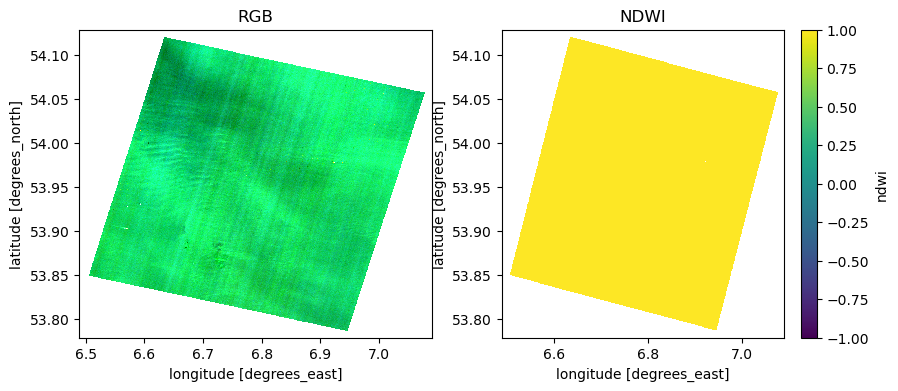

In [5]:
# dr.band_data.isel(band=10).plot()
print(ind665, ind560, ind440)
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
dr.band_data.isel(band = [ind665, ind560, ind440]).plot.imshow(ax=ax[0], robust=True)
ax[0].set_title('RGB')

Rrs_ndwi = dr.band_data.isel(band=[29,75]).values #dr.band_data.isel(band=[29, 75]).values
print('NDWI', wl[[29, 75]])
ndwi = (Rrs_ndwi[0,:,:] - Rrs_ndwi[1,:,:]) / (Rrs_ndwi[0, :,:] + Rrs_ndwi[1, :,:])
dr = dr.assign(ndwi=(['y', 'x'], ndwi))
dr.ndwi.plot(ax=ax[1], vmin=-1, vmax=1)
ax[1].set_title('NDWI')
plt.show()

# Processing

## Configuration Bi & Hieronymi

In [5]:
regionName='NorthSea'
sensor = 'EnMAP'
versionAC = 'EnMAPWaterv1.5.2'
dataType = 'EnMAPTile' # 'Sim'
## CAUTION: only Standardv2 is implemented here!! ##
AlgaeGroupType = 'Standardv2' #'Standardv2' # 'Standardv3' # 'NSSummerBloomsv3' Standardv2, 'HEREONgold'

# maxWavelength= 750.
maxWavelength = 850.

In [6]:
def set_default_parameters(AlgaeGroupType='Standardv3'):
    ## by Default:
    # - all Phytoplankton groups are value=0, min=0, max=1000 (C_5=10, C_7=1), vary = False
    # - C_Y value=0, min=0, max=30, vary=True
    # - C_ism value=0, min=0, max=100, vary=True
    # - fluorescence all vary = False
    # - offset vary = False
    params = lmfit.Parameters()                             # v3 ,      SummerBloom
    params.add('C_0', value=0, min=0, max=100, vary=False)  # Diatoms
    params.add('C_1', value=0, min=0, max=100, vary=False)  # green
    params.add('C_2', value=0, min=0, max=100, vary=False)  # cryptophyte
    params.add('C_3', value=0, min=0, max=100, vary=False)  # cyano blue
    params.add('C_4', value=0, min=0, max=100, vary=False)  # cyano red
    params.add('C_5', value=0, min=0, max=10, vary=False)   # coccolithophores , Phaeocystis: other ranges
    params.add('C_6', value=0, min=0, max=100, vary=False)  # dinoflagellates
    params.add('C_7', value=0, min=0, max=1, vary=False)    # case-1  , Noctiluca: other ranges
    params.add('C_Y', value=0, min=0, max=30, vary=True)
    params.add('C_ism', value=0, min=0, max=100, vary=True)
    params.add('L_fl_lambda0', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycocyanin', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycoerythrin', value=0, min=0, max=0.2, vary=False)
    params.add('b_ratio_C_0', value=0.002, vary=False)  # Diatoms 0.0058; HEREONweb: 0.002
    params.add('b_ratio_C_1', value=0.007, vary=False)  # green 0.007, HEREONweb: 0.007
    params.add('b_ratio_C_2', value=0.002, vary=False)  # cryptophyte 0.0042, HEREONweb: 0.002
    params.add('b_ratio_C_3', value=0.003, vary=False)  # cyano blue 0.0082, HEREONweb: 0.003
    params.add('b_ratio_C_4', value=0.003, vary=False)  # cyano red 0.001, HEREONweb: 0.003
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_5', value=0.0034, vary=False)  # Phaeocystis: change to 0.0034
    elif AlgaeGroupType == 'HEREONgold':
        params.add('b_ratio_C_5', value=0.002, vary=False)
    else:
        params.add('b_ratio_C_5', value=0.0129,
                   vary=False)  # coccolithophores 0.0129, , HEREONweb: 0.007, Phaeocystis: change to 0.0034
    params.add('b_ratio_C_6', value=0.0209, vary=False)  # dinoflagellates 0.0209, HEREONweb: not available
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_7', value=0.0209, vary=False)  # Noctiluca: change to 0.0209
    else:
        params.add('b_ratio_C_7', value=0.007,
                   vary=False)  # case-1 0.0109, HEREONweb: 0.007, Noctiluca: change to 0.0209
    params.add('b_ratio_md', value=0.0216, min=0.021, max=0.3756, vary=False)  # max=0.0756 #todo: vary turn off
    params.add('b_ratio_bd', value=0.0216, min=0.021, max=0.3756, vary=False)  # max=0.0756 #todo: vary turn off
    params.add('b_ratio_d', value=0.0216, min=0.021, max=0.3756, vary=False)
    params.add('A_md', value=13.4685e-3, vary=False)
    params.add('A_bd', value=0.3893e-3, vary=False)
    params.add('S_md', value=10.3845e-3, vary=False)
    params.add('S_bd', value=15.7621e-3, vary=False)
    params.add('S_cdom', value=0.020, min=0.018, max=0.022, vary=True) # Helsinki: 0.018 -0.022; test Baltic: min =0.01
    params.add('C_md', value=12.1700e-3, vary=False)
    params.add('C_bd', value=0.9994e-3, vary=False)
    params.add('K', value=0, min=0, vary=False)
    params.add('lambda_0_cdom', value=440, vary=False)
    params.add('lambda_0_md', value=550, vary=False)
    params.add('lambda_0_bd', value=550, vary=False)
    params.add('lambda_0_c_d', value=550, vary=False)
    params.add('lambda_0_phy', value=676, vary=False)
    params.add('gamma_d', value=0.3835, vary=False)
    params.add('x0', value=1, vary=False)
    params.add('x1', value=10, vary=False)
    params.add('x2', value=-1.3390, min=-1.3390 - 0.0618, max=-1.3390 + 0.0618, vary=False)
    params.add('A_phy', value=0.0237, vary=False)
    params.add('E0', value=1, vary=False)
    params.add('E1', value=0.8987, vary=False)
    params.add('W', value=0.75, vary=False)
    params.add('fwhm1', value=25, vary=False)
    params.add('fwhm2', value=50, vary=False)
    params.add('fwhm_phycocyanin', value=20, vary=False)
    params.add('fwhm_phycoerythrin', value=20, vary=False)
    params.add('lambda_C1', value=685, vary=False)
    params.add('lambda_C2', value=730, vary=False)
    params.add('lambda_C_phycocyanin', value=644, vary=False)
    params.add('lambda_C_phycoerythrin', value=573, vary=False)
    params.add('double', value=True, vary=False)
    params.add('interpolate', value=False, vary=False) # value=True
    params.add("Gw0", value=0.05881474, vary=False)
    params.add("Gw1", value=0.05062697, vary=False)
    params.add("Gp0", value=0.03997009, vary=False)
    params.add("Gp1", value=0.1398902, vary=False)
    params.add('error_method', value=0, vary=False)
    params.add('theta_sun', value=np.radians(30), min=np.radians(0), max=np.radians(90), vary=False)
    params.add('theta_view', value=np.radians(1e-10), min=np.radians(1e-10), max=np.radians(90), vary=False)
    params.add('n1', value=1, vary=False)
    params.add('n2', value=1.33, vary=False)
    params.add('kappa_0', value=1.0546, vary=False)
    params.add('fresh', value=False, vary=False)
    params.add('T_W', value=25, min=0, max=40, vary=False)
    params.add('T_W_0', value=20, vary=False)
    params.add('P', value=1013.25, vary=False)
    params.add('AM', value=1, vary=False)
    params.add('RH', value=60, vary=False)
    params.add('H_oz', value=0.38, vary=False)
    params.add('WV', value=2.5, vary=False)
    params.add('alpha', value=1.317, vary=False)
    params.add('beta', value=0.2606, vary=False)
    params.add('g_dd', value=0.02, min=-1, max=10, vary=False)  # glint correction
    params.add('g_dsr', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('g_dsa', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('d_r', value=0, min=0, max=0.1, vary=False)
    params.add('f_dd', value=1, vary=False)
    params.add('f_ds', value=1, vary=False)
    params.add('offset', value=0, min=-0.1, max=0.1, vary=False)
    params.add('fit_surface', value=False, vary=False)
    return params


def set_parameters_byDict(pDict, params):
    for key in pDict.keys():
        thisD = pDict[key]
        params.add(key, value=thisD['value'], min=thisD['min'], max=thisD['max'], vary=True)
    return params


def setDictValues(value, vmin, vmax):
    dd = {'value': value, 'min': vmin, 'max': vmax}
    return dd

In [7]:
## North Sea
processingDict = {
    'C_0': setDictValues(0.1,0,200), #brown
    # 'C_1': setDictValues(0.1,0,200), #green
    'C_2': setDictValues(0.1,0,200), # crypto
    # 'C_3': setDictValues(0,0,200), # cyano blue
    # 'C_4': setDictValues(0,0,100), # cyano red
    #'C_5': setDictValues(0,0,200), # coccolith.
    'C_6': setDictValues(0.1,0,200), # dinoflagellate
    'C_Y': setDictValues(0.1,0,1),
    'C_ism': setDictValues(0.1,0,150),
    'L_fl_lambda0': setDictValues(0,0,0.2),
    # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
    # 'L_fl_phycocyanin': setDictValues(0,0,0.2),
    # 'offset': setDictValues(0, -0.1, 0.1)
}

In [8]:
fit_config = {
    'C_0': dict(value=0, min=0, max=100, vary=True, log=False),  # Diatoms
    # 'C_1': dict(value=0, min=0, max=100, vary=True, log=True),  # green
    'C_2': dict(value=0, min=0, max=100, vary=True, log=False),  # cryptophyte
    # 'C_3': dict(value=0, min=0, max=100, vary=True, log=True),  # cyano blue
    # 'C_4': dict(value=0, min=0, max=100, vary=True, log=True),  # cyano red
    # 'C_5': dict(value=0, min=0, max=10, vary=True, log=True),   # coccolithophores , Phaeocystis: other ranges
    'C_6': dict(value=0, min=0, max=100, vary=True, log=False),  # dinoflagellates
    # 'C_7': dict(value=0, min=0, max=1, vary=True, log=True),    # case-1  , Noctiluca: other ranges
    'C_Y': dict(value=0, min=0, max=30, vary=True, log=False),
    'C_ism': dict(value=0, min=0, max=100, vary=True, log=False),
    'L_fl_lambda0':  dict(vary=True,  value=0.01,  min=0, max=1, log=False),
    'S_cdom': dict(value=0.020, min=0.018, max=0.022, log=False, vary=True),
    # 'offset': dict(vary=True, value=0, sigma_a=0.2, log=False)
}

noise     = 1 
n_iter    = 400 #15
tile_size = 4096

# PARAM_META = {
#     'zB':      ('Depth z_B',          'm',     cm.deep),
#     'f_mix_0': ('Mix logit (sand)',    'logit', 'RdYlGn'),
# }

# --- build lmfit Parameters --------------------------------------------------
paramDict = processingDict
params = set_default_parameters(AlgaeGroupType)
params = set_parameters_byDict(paramDict, params)


# sigma_a    = {n: c['sigma_a'] for n, c in fit_config.items() if c['vary']}
log_params = [n for n, c in fit_config.items() if c['vary'] and c['log']]


In [9]:
# --- precompute --------------------------
pre_base     = bi_jax.precompute(wavelengths)
# R_b_full     = np.array(pre_base['R_b_i'])
# R_b_selected = np.zeros_like(R_b_full)
# for dst, src in enumerate(bottom_types):
#     R_b_selected[:, dst] = R_b_full[:, src]
pre = {**pre_base}

all_names = list(params.keys())
f_vec     = bi_jax.make_forward_vec(all_names, pre)

dummy_sigma_a = {n: 1.0 for n in params if params[n].vary}
setup     = oe_engine.build_inversion(params, f_vec, dummy_sigma_a, log_params=log_params)


print('Free parameters:', setup.fit_names)
print('log_params:',      log_params)

Free parameters: ['C_0', 'C_2', 'C_6', 'C_Y', 'C_ism', 'L_fl_lambda0', 'S_cdom']
log_params: []


## Step 1 — SLIC segmentation

`compactness=0.1` allows superpixel shapes to follow natural spectral edges  
(water eddies, depth gradients) rather than enforcing compact blobs.  
`sigma=2.0` reduces the impact of per-pixel spectral noise on cluster assignment.

In [10]:
# SLIC parameters (paper defaults)
IDvalid = np.logical_not(np.isnan(Rrs_image[:,:,0]))

n_segments  = np.sum(IDvalid) / 100. #1200   # ~1% of 119 883 pixels
compactness = 0.1 
slic_sigma  = 2.0

t0     = time.perf_counter()
labels = superpixel_engine.segment_image(
    Rrs_image, n_segments=n_segments,
    compactness=compactness, sigma=slic_sigma,
)
t_seg  = time.perf_counter() - t0

n_segs_actual = len(np.unique(labels))
print(f'Requested {n_segments} segments → got {n_segs_actual}  ({t_seg:.2f} s)')
print(f'Mean pixels per segment: {n_pixels / n_segs_actual:.0f}')

Requested 2868.74 segments → got 2743  (22.13 s)
Mean pixels per segment: 559


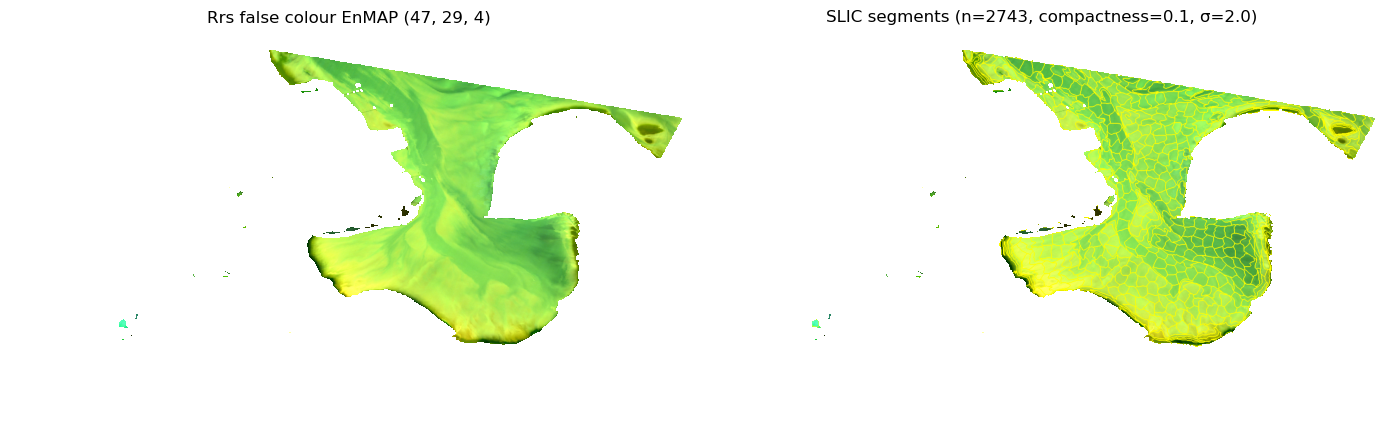

In [11]:
# False-colour RGB for overlay
rgb_bands = [ind665, ind560, ind440]   # B04, B03, B02 → R, G, B
rgb = Rrs_image[..., rgb_bands]
rgb = (rgb - np.nanpercentile(rgb, 2)) / (np.nanpercentile(rgb, 98) - np.nanpercentile(rgb, 2))
rgb = np.clip(rgb, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(rgb, origin='upper')
BandStr = str(ind665) + ', ' + str(ind560) + ', ' + str(ind440)
axes[0].set_title('Rrs false colour EnMAP ('+BandStr +')')
axes[0].axis('off')

# mark_boundaries draws segment outlines on the image
img_boundaries = mark_boundaries(rgb, labels, color=(1, 1, 0), mode='thick')
axes[1].imshow(img_boundaries, origin='upper')
axes[1].set_title(f'SLIC segments (n={n_segs_actual}, compactness={compactness}, σ={slic_sigma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Step 1.1 — Aggregate superpixel mean spectra

sp_spectra shape: (2743, 73)
valid sp_spectra: 660
Pixel counts (in valid superpixel) — min: 1  median: 483  max: 1653


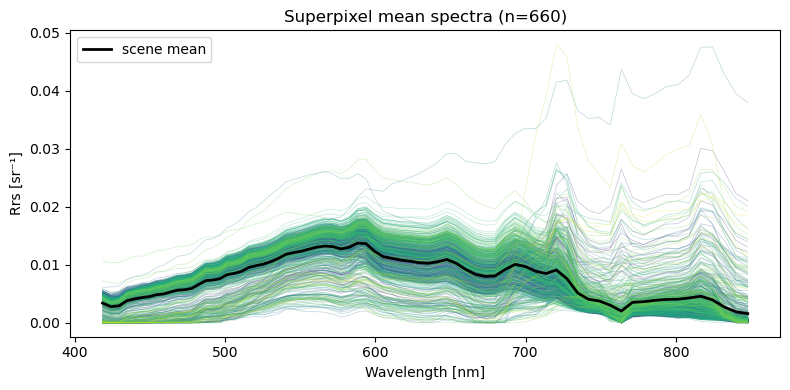

In [12]:
sp_spectra, sp_counts = superpixel_engine.aggregate_superpixels(Rrs_image, labels)

valid = np.where(np.sum(np.logical_not(np.isnan(sp_spectra)), axis=1)>0)[0]
print(f'sp_spectra shape: {sp_spectra.shape}')
print(f'valid sp_spectra: {len(valid)}')
print(f'Pixel counts (in valid superpixel) — min: {sp_counts[valid].min()}  median: {np.nanmedian(sp_counts[valid]):.0f}  max: {sp_counts[valid].max()}')

fig, ax = plt.subplots(figsize=(8, 4))
cvals = np.linspace(0, 1, n_segs_actual)
n_segs_actual_noNaN = 0
for i in range(n_segs_actual):
    if np.sum(np.logical_not(np.isnan(sp_spectra[i])))>0:
        n_segs_actual_noNaN +=1
        ax.plot(wavelengths, sp_spectra[i], color=plt.cm.viridis(cvals[i]), alpha=0.3, lw=0.5)
ax.plot(wavelengths, np.nanmean(sp_spectra, axis=0), 'k-', lw=2, label='scene mean')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Rrs [sr⁻¹]')
ax.set_title(f'Superpixel mean spectra (n={n_segs_actual_noNaN})')
ax.legend()
plt.tight_layout()
plt.show()

### Step 1.2 — Write mean spectra to file

In [109]:
## write mean spectra to file
import pandas as pd
valid = np.where(np.sum(np.logical_not(np.isnan(sp_spectra)), axis=1)>0)[0]
outdf = pd.DataFrame(sp_spectra[valid,:], columns=[str(a) for a in wavelengths])
outpath = "D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\\"
#zarrFname: enmapZarr_ENMAP01-____L2A-DT0000090299_20240831T112133Z_002_V010502_20250116T085503Z.zarr
outfile = zarrFname.split('enmapZarr_ENMAP01-____L2A-')[1].split('.zarr')[0]
outdf.to_csv(outpath + "EnMAPsuperpixel_"+outfile +'_c.txt',  sep='\t', header=True, index=False)

## Step 2 — Least Square inversion of superpixel mean spectra

Each superpixel is inverted independently using the same `setup`.  
The noise passed here is the **original pixel noise** — the chi2 values will be  
smaller than for per-pixel inversion because mean spectra are smoother.  
The calibrated chi2 = chi2_raw × N_pixels accounts for this.

**NOTE: not working yet**


**Inversion is handled outside this notebook!**

### Inversion

In [76]:
## Restricted to valid pixels ## 
t0 = time.perf_counter()
sp_results = superpixel_engine.invert_superpixels(
    sp_spectra[valid,:], sp_counts[valid], setup, noise,
    invert_fn = lsq_engine_optx.invert_image,
    max_steps=n_iter, tile_size=tile_size
)
t_sp = time.perf_counter() - t0

print(f'Superpixel inversion: {n_segs_actual_noNaN} segments in {t_sp:.2f} s')
print(f'Speedup vs full image (~{n_pixels_valid} px): {n_pixels_valid / n_segs_actual_noNaN:.0f}× fewer inversions')

  312/312 (100%)
Superpixel inversion: 312 segments in 18.66 s
Speedup vs full image (~286874 px): 919× fewer inversions


In [14]:
sp_results

{'x_hat': array([[ 2.48287360e-03,  2.12006106e-03,  2.57236913e-03, ...,
          1.42323436e+02,  9.51627425e-18,  1.27127968e-01],
        [ 2.02747138e-04,  1.67497953e-04,  2.00156718e-04, ...,
          1.39416509e+02,  8.54099118e-19,  1.22699040e-01],
        [ 7.71918280e+02,  1.84656103e-05,  4.58380115e+02, ...,
          2.10340865e+02,  2.75475342e-16,  1.02148542e-01],
        ...,
        [ 1.15021088e-01,  1.06896020e-01,  2.49965873e-01, ...,
          2.16822780e+03, -1.38593075e-20,  5.21983667e-03],
        [ 1.14293122e+03,  1.00744937e+00,  2.97232883e+02, ...,
          3.78079733e-01, -2.09073835e-17,  1.08289599e-01],
        [ 1.06192947e-01,  1.01869516e-01,  2.12751099e-01, ...,
          2.48867378e+07,  1.28370774e-18,  2.97758387e+00]],
       shape=(313, 7)),
 'chi2': array([3.66241255e-04, 3.34646358e-04,            nan, 4.96459837e-04,
        3.87300682e-04, 4.45392415e-04, 5.39145627e-04,            nan,
        2.88465478e-04,            nan, 4.934

## Step 3 -- Read Inversion results

In [13]:
## read full inversion old way
import pandas as pd
inpath = "D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\FullInversion\\"
fnames = os.listdir(inpath)
## b: with fluorescence, c: no fluorescence
rrsFname = [fn for fn in fnames if fn.startswith('inverted_Sim') and fn.endswith('c.txt') and 'c_withOWT' in fn][0]
print(rrsFname)
invRrs = pd.read_csv(inpath+ rrsFname, header=0)
invWL = np.asarray([float(a) for a in invRrs.columns.values])
iopFname = [fn for fn in fnames if fn.startswith('inverted_IOP') and fn.endswith('c.txt') and 'c_withOWT' in fn][0]

invIOP =  pd.read_csv(inpath+ iopFname, header=0)
print(invIOP.shape)
print(invRrs.shape)

inverted_Sim_bio_optics_HEREONfull__c_withOWT_allOWTs_Inv0.1c.txt
(660, 84)
(660, 73)


10


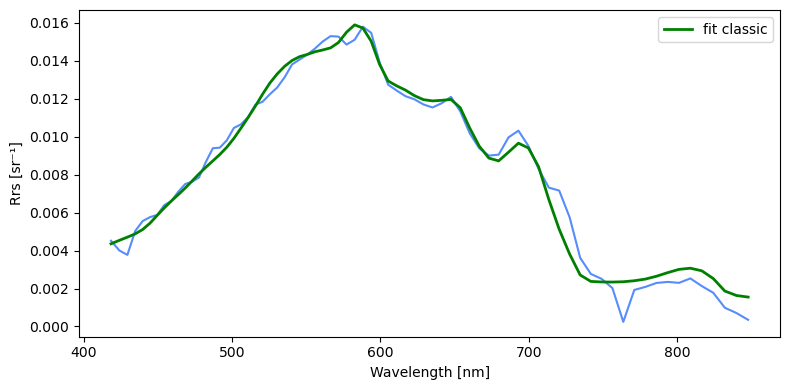

In [113]:
## only valid spectra inverted:
# minchi = sp_results['chi2'] == np.min(sp_results['chi2'])
# i = np.where(minchi)[0][0]
i = 10
print(i)
vi = i

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wavelengths, sp_spectra[valid,:][i,:])
# ax.plot(wavelengths, sp_results['y_hat'][i], 'k-', lw=2, label='fit')
ax.plot(invWL, invRrs.iloc[vi,:], 'g-', lw=2, label='fit classic')
# ax.set_title('chi2 ' +str(np.round(sp_results['chi2'][i], 4)))
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Rrs [sr⁻¹]')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
## spectral errors
def setup_spectral_error_df(Xtrain, X_projected):
    SpectralErrorDF = pd.DataFrame()

    rMAE = np.zeros(Xtrain.shape[0])
    sam = np.zeros(Xtrain.shape[0])

    rMAE = np.sqrt(np.sum((Xtrain - X_projected) ** 2, axis=1)) / np.sum(Xtrain, axis=1)
    sqrtsum2_orig = np.sqrt(np.sum(Xtrain ** 2, axis=1))
    sqrtsum2_inv = np.sqrt(np.sum(X_projected ** 2, axis=1))
    sam = np.sum((Xtrain * X_projected), axis=1) / (sqrtsum2_orig * sqrtsum2_inv)
    sam = np.arccos(sam)

    sam *= 180. / np.pi
    SpectralErrorDF['rMAE'] = rMAE
    SpectralErrorDF['SAM'] = sam
    SpectralErrorDF['absErr'] = np.sum(np.abs(X_projected - Xtrain), axis=1)
    SpectralErrorDF['noise'] = np.sum(np.abs(np.diff(Xtrain)), axis=1)

    return SpectralErrorDF

In [17]:
errorDF = setup_spectral_error_df(sp_spectra[valid,:],invRrs.values)

C:\Users\Dagmar\AppData\Local\Temp\ipykernel_3372\488529948.py:11: RuntimeWarning: invalid value encountered in divide
  sam = np.sum((Xtrain * X_projected), axis=1) / (sqrtsum2_orig * sqrtsum2_inv)


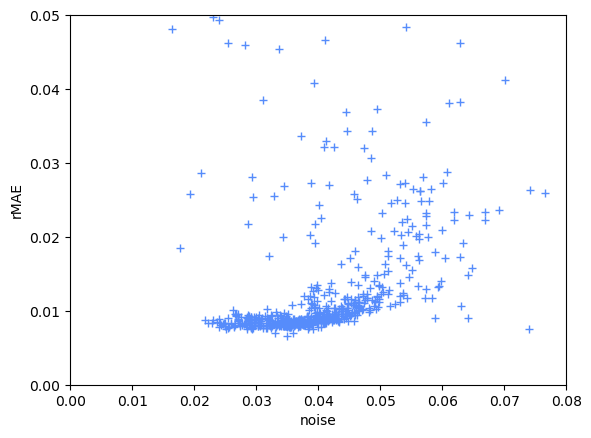

In [20]:
plt.plot(errorDF.noise, errorDF.rMAE, '+')
plt.xlabel('noise')
plt.ylabel('rMAE')
plt.xlim((0,0.08))
plt.ylim((0,0.05))
plt.show()

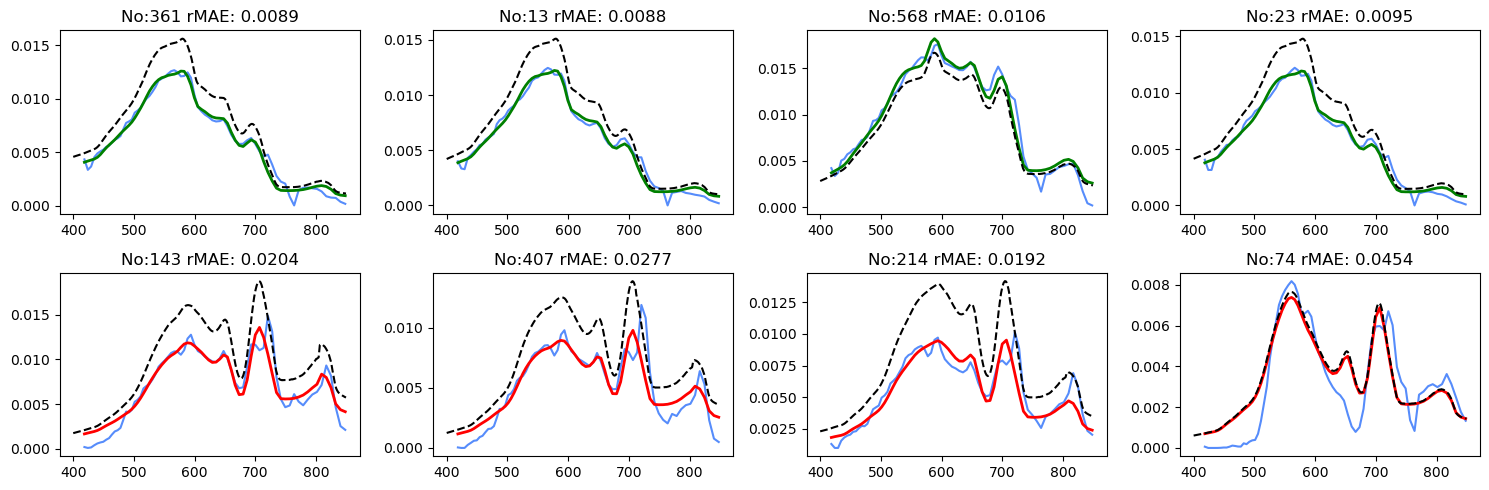

In [37]:
IDgood = errorDF.rMAE.values < 0.015
IDbad = errorDF.rMAE.values > 0.015
N = 4
ind_good = np.random.choice(np.where(IDgood)[0], size=N, replace=False)
ind_bad = np.random.choice(np.where(IDbad)[0], size=N, replace=False)

fig, ax = plt.subplots(nrows=2, ncols=N, figsize=(15, 5))
for ix in range(N):
    ax[0, ix].plot(wavelengths, sp_spectra[valid,:][ind_good[ix],:], '-')
    ax[0, ix].plot(invWL, invRrs.iloc[ind_good[ix],:], 'g-', lw=2, label='fit classic')
    ax[0, ix].plot(wl1nm, Rrs_sim_jax_Arr[ind_good[ix],:], 'k--')
    ax[0, ix].set_title('No:' + str(ind_good[ix]) + ' rMAE: '+ str(np.round(errorDF.rMAE.values[ind_good[ix]],4)))
    ax[1, ix].plot(wavelengths, sp_spectra[valid,:][ind_bad[ix],:], '-')
    ax[1, ix].plot(invWL, invRrs.iloc[ind_bad[ix],:], 'r-', lw=2, label='fit classic')
    ax[1, ix].plot(wl1nm, Rrs_sim_jax_Arr[ind_bad[ix],:], 'k--')
    ax[1, ix].set_title('No:' + str(ind_bad[ix]) + ' rMAE: '+ str(np.round(errorDF.rMAE.values[ind_bad[ix]],4)))
fig.tight_layout()
plt.show()

In [30]:
print(np.sum(IDgood), np.sum(IDbad))

430 230


### check Inversion results and spectra

C:\Users\Dagmar\AppData\Local\Temp\ipykernel_4500\1395112846.py:24: RuntimeWarning: invalid value encountered in log10
  ax[iy, ix].hist(np.log10(sp_results['x_hat'][:,i]), 30)


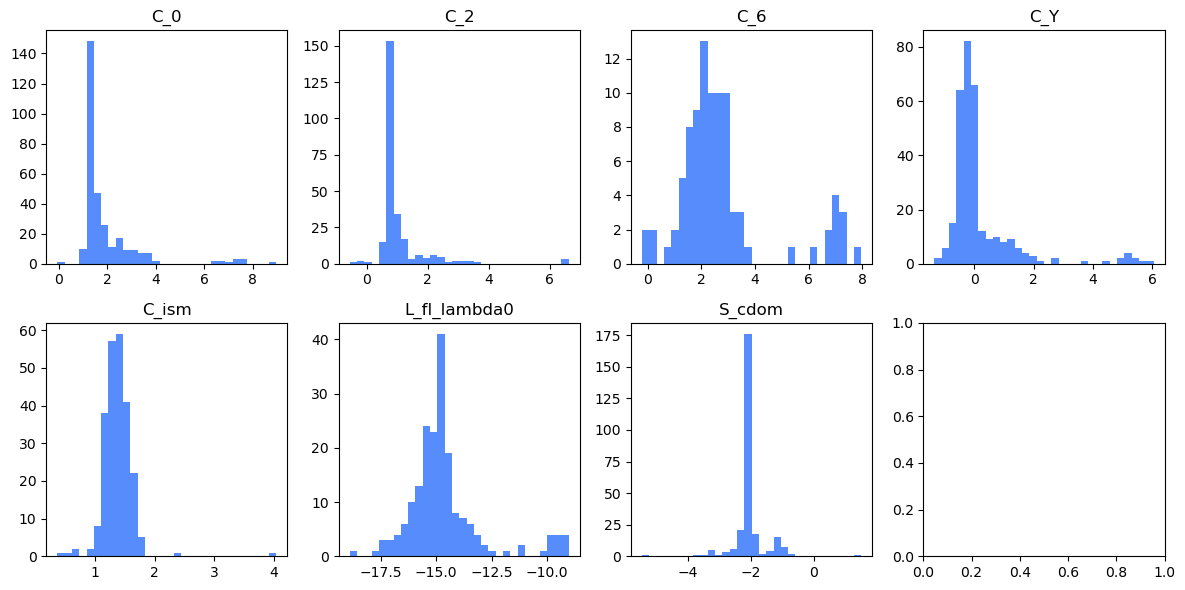

In [79]:
# # Overview inversion
# Nx, Ny = (4,2)
# fig, ax = plt.subplots(Ny, Nx, figsize=(12,6))
# ix, iy = (0,0)
# for i, key in enumerate(fit_config.keys()):
#     if fit_config[key]['log']:
#         ax[iy, ix].hist(np.log10(sp_results['x_hat'][valid,i]), 30)
#     else:
#         ax[iy, ix].hist(sp_results['x_hat'][valid,i], 30)
#     ax[iy, ix].set_title(key)
#     ix +=1
#     if ix == Nx:
#         ix=0
#         iy+=1
# fig.tight_layout()
# plt.show()

# Overview inversion; valid only
Nx, Ny = (4,2)
fig, ax = plt.subplots(Ny, Nx, figsize=(12,6))
ix, iy = (0,0)
for i, key in enumerate(fit_config.keys()):
    #if fit_config[key]['log']:
    ax[iy, ix].hist(np.log10(sp_results['x_hat'][:,i]), 30)
    # else:
    # ax[iy, ix].hist(sp_results['x_hat'][:,i], 30)
    ax[iy, ix].set_title(key)
    ix +=1
    if ix == Nx:
        ix=0
        iy+=1
fig.tight_layout()
plt.show()

Median chi2 raw:        1.0164
Median chi2 calibrated: 720.1524  (should be ≈ 1 if noise is well-calibrated)


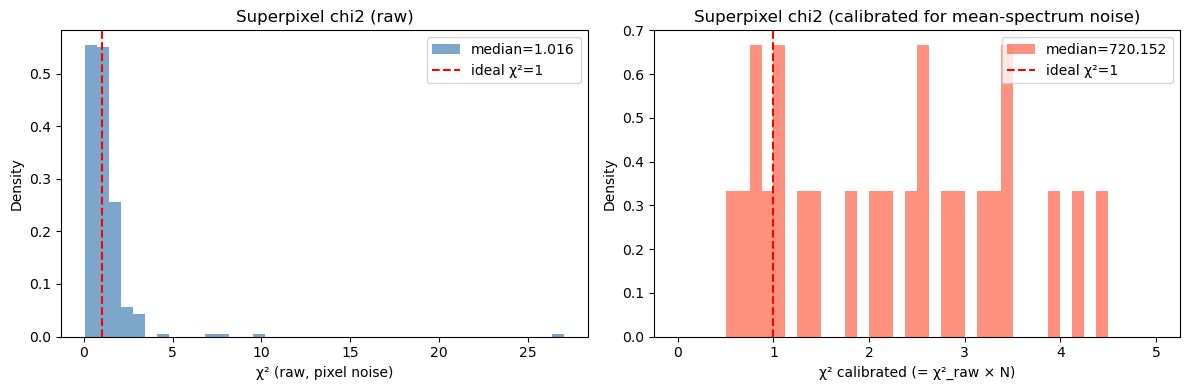

In [54]:
chi2_raw = sp_results['chi2']
chi2_cal = chi2_raw * sp_counts[valid]   # calibrated: chi2 × N

print(f'Median chi2 raw:        {np.nanmedian(chi2_raw):.4f}')
print(f'Median chi2 calibrated: {np.nanmedian(chi2_cal):.4f}  (should be ≈ 1 if noise is well-calibrated)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

kw = dict(bins=40, density=True, alpha=0.7)
axes[0].hist(chi2_raw, **kw, color='steelblue', label=f'median={np.nanmedian(chi2_raw):.3f}')
axes[0].axvline(1.0, color='r', ls='--', lw=1.5, label='ideal χ²=1')
axes[0].set_xlabel('χ² (raw, pixel noise)')
axes[0].set_ylabel('Density')
axes[0].set_title('Superpixel chi2 (raw)')
axes[0].legend()

axes[1].hist(chi2_cal, range=(0, 5), **kw, color='tomato', label=f'median={np.nanmedian(chi2_cal):.3f}')
axes[1].axvline(1.0, color='r', ls='--', lw=1.5, label='ideal χ²=1')
axes[1].set_xlabel('χ² calibrated (= χ²_raw × N)')
axes[1].set_ylabel('Density')
axes[1].set_title('Superpixel chi2 (calibrated for mean-spectrum noise)')
axes[1].legend()

plt.tight_layout()
plt.show()



## Chain 1 - Forward superpixel, interpolate spectra

### Step 4 - Forward Simulations
Calculate spectra at 1nm resolution!

In [32]:
wl1nm = np.arange(400., 850., 1.)
pre_base = bi_jax.precompute(wl1nm)
pre = {**pre_base}

In [39]:
paramDF = invIOP.copy()
paramDF.drop(columns = ['C_phy'], inplace=True)
print(len(valid))
Rrs_sim_jax_Arr = np.zeros((len(valid), len(wl1nm)))

for i in range(paramDF.shape[0]):  #paramDF.shape[0]:
    # print(i, 'C_phy', invIOP['C_phy'].values[i])
    # print('C_ism', invIOP['C_ism'].values[i])
    # print('C_Y', invIOP['C_Y'].values[i])
    for p in paramDF.columns.values:
        # Change parameters object accordingly.
        # if p.startswith('C_'):
        #     print(p, np.round(paramDF[p].values[i] / invIOP['C_phy'].values[i], 2))
        params.add(p, value=paramDF[p].values[i])

    R_rs_sim_jax = bi_jax.forward(params, pre)
    Rrs_sim_jax_Arr[i,:] = R_rs_sim_jax

660
b_ratio_C_0 0.002
b_ratio_C_1 0.007
b_ratio_C_2 0.002
b_ratio_C_3 0.003
b_ratio_C_4 0.003
b_ratio_C_5 0.0129
b_ratio_C_6 0.0209
b_ratio_C_7 0.007
b_ratio_md 0.0216
b_ratio_bd 0.0216
b_ratio_d 0.021


#### Consistency Bi&Hi Implementations

In [51]:
## forward sim old bio_optics Bi&Hi
bihi = pd.read_csv("D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\FullInversion\SimRrs_InsituForward_HEREON_inverted_IOP_bio_optics_HEREONfull_withOWT_allOWTs_Inv0_Inv0.1c.txt", header=0, sep='\t') #Inv0.1b: with fluor, Inv0.1c: no fluor
bihiwl = np.asarray([float(a) for a in bihi.columns.values])
bihi

,400.0,401.0,402.0,403.0,404.0,405.0,406.0,407.0,408.0,409.0,...,890.0,891.0,892.0,893.0,894.0,895.0,896.0,897.0,898.0,899.0
0,0.001949,0.001972,0.001994,0.002017,0.002040,0.002062,0.002084,0.002106,0.002128,0.002150,...,0.001309,0.001295,0.001283,0.001270,0.001257,0.001245,0.001233,0.001221,0.001210,0.001198
1,0.001485,0.001501,0.001517,0.001533,0.001549,0.001564,0.001580,0.001595,0.001610,0.001625,...,0.001156,0.001145,0.001133,0.001122,0.001111,0.001100,0.001090,0.001079,0.001069,0.001059
2,0.001877,0.001880,0.001883,0.001885,0.001886,0.001887,0.001888,0.001889,0.001889,0.001890,...,0.009581,0.009493,0.009407,0.009321,0.009238,0.009155,0.009074,0.008994,0.008916,0.008839
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.002932,0.002959,0.002987,0.003013,0.003039,0.003064,0.003090,0.003114,0.003139,0.003163,...,0.001174,0.001163,0.001151,0.001140,0.001129,0.001118,0.001107,0.001096,0.001086,0.001076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
309,0.001955,0.001959,0.001962,0.001965,0.001968,0.001969,0.001971,0.001972,0.001973,0.001974,...,0.010724,0.010628,0.010534,0.010442,0.010351,0.010261,0.010173,0.010086,0.010001,0.009916
310,0.002114,0.002111,0.002109,0.002105,0.002101,0.002097,0.002092,0.002087,0.002082,0.002077,...,0.013554,0.013442,0.013333,0.013224,0.013118,0.013013,0.012909,0.012807,0.012707,0.012607
311,0.001813,0.001816,0.001819,0.001820,0.001822,0.001823,0.001823,0.001823,0.001823,0.001822,...,0.008933,0.008854,0.008775,0.008698,0.008622,0.008547,0.008473,0.008401,0.008330,0.008259


In [59]:
# biweb = pd.read_csv("D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\compare_implementations\IOP_spectra_outputs_BiWeb_SuperPixel0_20240831T112133Z_002.csv",
# header=0) # with fluorescence
biweb = pd.read_csv("D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\compare_implementations\IOP_spectra_outputs_BiWeb_SuperPixel0_20240831T112133Z_002_noFluor.csv", header=0)
biweb

,wavelen,aph,ad,acdom,bph,bd,aw,bw,ap,agp,bp,at,bt,bbph,bbd,bbp,bbw,bbt,Rrs_L11,Rrs_AM03
0,350,5.840426e-01,2.136703,7.065522,4.210812,9.179709,0.000879,0.009947,2.720745,9.786268,13.390520,9.787146,13.400468,0.011874,0.198282,0.210156,0.004974,0.215130,0.000931,0.000977
1,352,5.840431e-01,2.094524,6.780947,4.210163,9.197186,0.000910,0.009701,2.678567,9.459515,13.407348,9.460425,13.417049,0.011873,0.198659,0.210532,0.004850,0.215382,0.000965,0.001014
2,354,5.840442e-01,2.053297,6.509427,4.209517,9.213905,0.000950,0.009461,2.637341,9.146768,13.423423,9.147718,13.432884,0.011871,0.199020,0.210891,0.004731,0.215622,0.001001,0.001052
3,356,5.840462e-01,2.012998,6.251283,4.208875,9.229887,0.000991,0.009230,2.597044,8.848328,13.438762,8.849319,13.447991,0.011869,0.199366,0.211235,0.004615,0.215849,0.001037,0.001092
4,358,5.840501e-01,1.973607,6.006052,4.208235,9.245149,0.001035,0.009005,2.557657,8.563709,13.453384,8.564745,13.462389,0.011867,0.199695,0.211562,0.004503,0.216065,0.001074,0.001132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,892,1.195478e-06,0.222553,0.000270,4.694462,7.682302,6.302232,0.000197,0.222554,0.222824,12.376764,6.525056,12.376961,0.013238,0.165938,0.179176,0.000098,0.179274,0.001169,0.001241
272,894,1.091774e-06,0.222428,0.000260,4.694236,7.675640,6.407523,0.000195,0.222430,0.222689,12.369876,6.630212,12.370071,0.013238,0.165794,0.179032,0.000097,0.179129,0.001148,0.001218
273,896,9.971046e-07,0.222307,0.000250,4.694010,7.668996,6.502164,0.000193,0.222308,0.222558,12.363006,6.724722,12.363199,0.013237,0.165650,0.178887,0.000097,0.178984,0.001130,0.001199
274,898,9.106787e-07,0.222188,0.000241,4.693785,7.662371,6.608917,0.000191,0.222188,0.222429,12.356156,6.831346,12.356347,0.013236,0.165507,0.178744,0.000096,0.178839,0.001111,0.001178


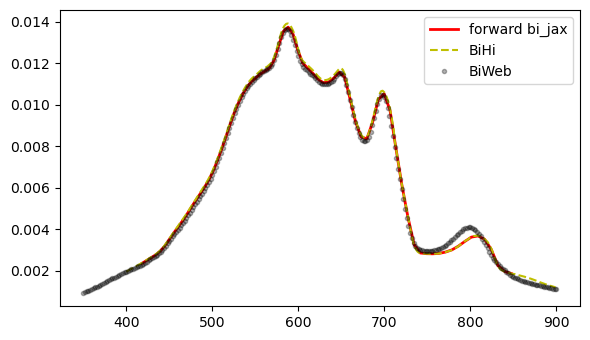

In [64]:
fig, ax = plt.subplots(figsize=(6, 3.5))
# ax.plot(wavelengths, sp_spectra[valid,:][i,:], label='EnMAP')
# ax.plot(invWL, invRrs.iloc[vi,:], 'g-', lw=2, label='fit classic')

ax.plot(invWL, R_rs_sim_jax, 'r-', lw=2, label='forward bi_jax')
ax.plot(bihiwl, bihi.iloc[i,:], 'y--', label='BiHi')
ax.plot(biweb.wavelen, biweb.Rrs_L11, 'k.', alpha=0.3, label='BiWeb')
ax.legend()

fig.tight_layout()
plt.show()

### Step 5 - Convolve simulations

#### Convolution to CHIME

In [116]:
SNR = pd.read_csv("Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\CHIME_SNR\SNR_g_No_coeff.csv", header=0)
SNR

,Wavelength [nm],g,N0
0,404.2,298.624928,1.477043
1,412.6,340.045687,1.139124
2,421.0,359.345786,1.020047
3,429.4,362.448827,1.007215
4,437.8,397.359474,0.868355
...,...,...,...
245,2462.2,69.403332,8.525178
246,2470.6,48.706035,17.310059
247,2479.0,32.256519,39.466544
248,2487.4,13.538347,224.043744


In [117]:
def ISRF(wl, wl0):
    FWHM = 10.7
    sigma = FWHM/(2*np.sqrt(2*np.log(2)))
    return 1./np.sqrt(2*np.pi*sigma)*np.exp(-1./2.*((wl-wl0)/sigma)**2)

CHIME_vnir = SNR.iloc[:,0].values[SNR.iloc[:,0].values < maxWavelength]

Rrs_CHIME = np.zeros((len(valid), len(CHIME_vnir)))
weights_Arr = np.zeros((len(wl1nm), len(CHIME_vnir)))
for i, wl0 in enumerate(CHIME_vnir):
    weights = ISRF(wl1nm, wl0)
    weightsnorm = weights / np.sum(weights)
    weights_Arr[:,i] = weightsnorm

Rrs_CHIME = np.matmul(Rrs_sim_jax_Arr, weights_Arr)


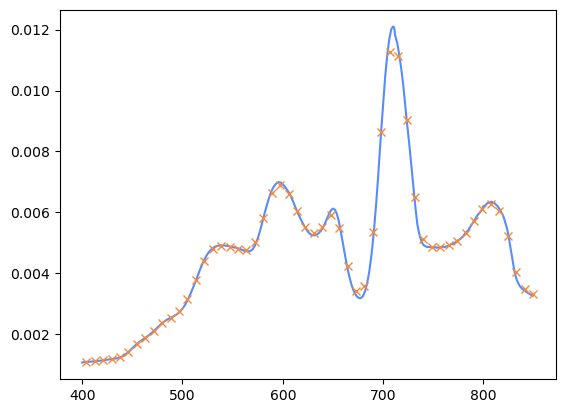

In [118]:
plt.plot(wl1nm, Rrs_sim_jax_Arr[0,:], '-')
plt.plot(CHIME_vnir, Rrs_CHIME[0,:], 'x' )
plt.show()

#### Convolution to EnMAP
for spatial Error characterisation

In [27]:
EnMAP_SRF = pd.read_csv("E:\Documents\projects\EnsAD\c2rcc_test\EnMAP_SRF\EnMAP_Spectral_Bands.txt", header=0, sep='\t')
EnMAP_SRF

,BAND #,CW (nm),FWHM (nm)
0,1,420.93,7.00
1,2,426.46,6.69
2,3,431.80,6.45
3,4,436.96,6.28
4,5,441.98,6.16
...,...,...,...
86,87,964.34,10.71
87,88,972.49,10.70
88,89,980.63,10.67
89,90,988.77,10.62


In [119]:
def ISRF_EnMAP(wl, wl0):
    ind_, ind = find_closest(EnMAP_SRF['CW (nm)'], wl0)
    FWHM = EnMAP_SRF['FWHM (nm)'].values[ind]
    sigma = FWHM/(2*np.sqrt(2*np.log(2)))
    return 1./np.sqrt(2*np.pi*sigma)*np.exp(-1./2.*((wl-wl0)/sigma)**2)

EnMAP_vnir = wavelengths

Rrs_EnMAP = np.zeros((len(valid), len(EnMAP_vnir)))
weights_Arr = np.zeros((len(wl1nm), len(EnMAP_vnir)))
for i, wl0 in enumerate(EnMAP_vnir):
    weights = ISRF_EnMAP(wl1nm, wl0)
    weightsnorm = weights / np.sum(weights)
    weights_Arr[:,i] = weightsnorm

Rrs_EnMAP = np.matmul(Rrs_sim_jax_Arr, weights_Arr)

### Step 6 — Back-interpolation **Spectra**: PCA + kNN IDW

For each pixel, find the k=4 nearest superpixels in 6-component PCA space  
(fitted on brightness-normalised mean spectra), then compute an inverse-distance  
weighted average of their retrieval results.

Uncertainty propagation:
- **Formal**: `σ²_pixel = Σ wᵢ² σ²_spᵢ` — posterior uncertainty propagated through IDW weights
- **Interpolation spread**: `+ Σ wᵢ (x_hat_spᵢ − x_hat_pixel)²` — spread among k neighbours

In [120]:
## Interpolation CHIME convolved spectra ##
k            = 4
n_components = 10

t0 = time.perf_counter()
bp = superpixel_engine.backinterp_pca_knn(
    Rrs_image.reshape(n_pixels, n_obs),
    sp_spectra[valid,:],
    Rrs_CHIME,
    # sp_results['x_hat'],
    # sp_sigma=sp_results['sigma'],
    # sp_A_diag=sp_results['A_diag'],
    k=k, n_components=n_components,
)
t_interp = time.perf_counter() - t0


CHIME_estim_flat  = bp['x_hat']
# sigma_flat  = bp['sigma']
# A_diag_flat = bp['A_diag']

n_fit   = CHIME_estim_flat.shape[-1]
CHIME_estim  = CHIME_estim_flat.reshape(n_rows, n_cols, n_fit)
# sigma_sp  = sigma_flat.reshape(n_rows, n_cols, n_fit)
# A_diag_sp = A_diag_flat.reshape(n_rows, n_cols, n_fit)

print(f'Back-interpolation: {t_interp:.2f} s')
print(f'x_hat shape: {CHIME_estim.shape}')

Back-interpolation: 17.05 s
x_hat shape: (930, 1648, 54)


In [121]:
## Interpolation EnMAP convolved spectra for spectral Errors ##
k            = 4
n_components = 10

t0 = time.perf_counter()
bp = superpixel_engine.backinterp_pca_knn(
    Rrs_image.reshape(n_pixels, n_obs),
    sp_spectra[valid,:],
    Rrs_EnMAP,
    # sp_results['x_hat'],
    # sp_sigma=sp_results['sigma'],
    # sp_A_diag=sp_results['A_diag'],
    k=k, n_components=n_components,
)
t_interp = time.perf_counter() - t0


EnMAP_estim_flat  = bp['x_hat']
# sigma_flat  = bp['sigma']
# A_diag_flat = bp['A_diag']

n_fit   = EnMAP_estim_flat.shape[-1]
EnMAP_estim  = EnMAP_estim_flat.reshape(n_rows, n_cols, n_fit)
# sigma_sp  = sigma_flat.reshape(n_rows, n_cols, n_fit)
# A_diag_sp = A_diag_flat.reshape(n_rows, n_cols, n_fit)

print(f'Back-interpolation: {t_interp:.2f} s')
print(f'x_hat shape: {EnMAP_estim.shape}')

Back-interpolation: 17.72 s
x_hat shape: (930, 1648, 73)


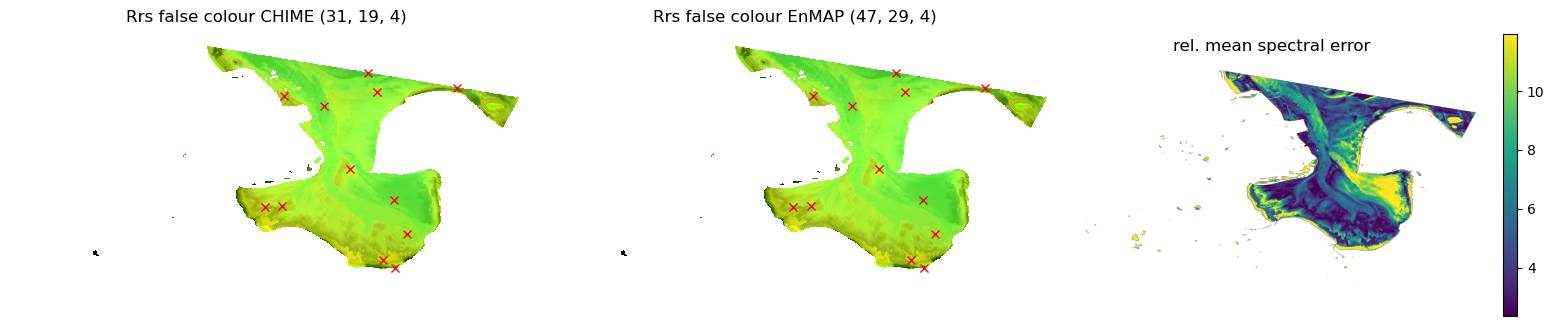

In [122]:
## RGB CHIME
ind665_C, ind665C = find_closest(CHIME_vnir, 665)
ind560_C, ind560C = find_closest(CHIME_vnir, 560)
ind440_C, ind440C = find_closest(CHIME_vnir, 440)

IDnan = np.isnan(Rrs_image[:,:,0])

def rgb_setup(Rrs_estim, IDnan, ind665C, ind560C, ind440C):
    # False-colour RGB for overlay
    rgb_bands = [ind665C, ind560C, ind440C]   # B04, B03, B02 → R, G, B
    rgb = Rrs_estim[..., rgb_bands]
    for i in range(rgb.shape[2]):
        rgb[IDnan, i] = np.nan
    rgb = (rgb - np.nanpercentile(rgb, 2)) / (np.nanpercentile(rgb, 98) - np.nanpercentile(rgb, 2))
    rgb = np.clip(rgb, 0, 1)
    return rgb

## random choice spectrum from water: EnMAP, CHIME
waterID = np.where(np.logical_not(IDnan))
selectID = np.random.choice(np.arange(0, len(waterID[0]),1), size=12, replace=False)
waterX = waterID[0][selectID]
waterY = waterID[1][selectID]

## Plot images

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

rgb_CHIME = rgb_setup(CHIME_estim, IDnan, ind665C, ind560C, ind440C)
axes[0].imshow(rgb_CHIME, origin='upper')
axes[0].plot(waterY, waterX, 'rx')
# axes.text(waterY, waterX, [str(i) for i in range(12)], color='red')

BandStr = str(ind665C) + ', ' + str(ind560C) + ', ' + str(ind440C)
axes[0].set_title('Rrs false colour CHIME ('+BandStr +')')
axes[0].axis('off')


rgb_EnMAP = rgb_setup(EnMAP_estim, IDnan, ind665, ind560, ind440)
axes[1].imshow(rgb_EnMAP, origin='upper')
axes[1].plot(waterY, waterX, 'rx')
# axes.text(waterY, waterX, [str(i) for i in range(12)], color='red')

BandStr = str(ind665) + ', ' + str(ind560) + ', ' + str(ind440)
axes[1].set_title('Rrs false colour EnMAP ('+BandStr +')')
axes[1].axis('off')


## Error EnMAP to CHIME
# only possible with EnMAP to EnMAP!
specMax = np.max(Rrs_image, axis=-1)
errorSpec = np.sum(np.abs(Rrs_image - EnMAP_estim), axis=-1)/specMax
vmin, vmax = np.nanpercentile(errorSpec, [2, 90])
im = axes[2].imshow(errorSpec, origin='upper', vmin=vmin, vmax=vmax)
axes[2].set_title('rel. mean spectral error')
axes[2].axis('off')
fig.colorbar(im, ax=axes[2], shrink=0.6)
plt.tight_layout()
plt.show()


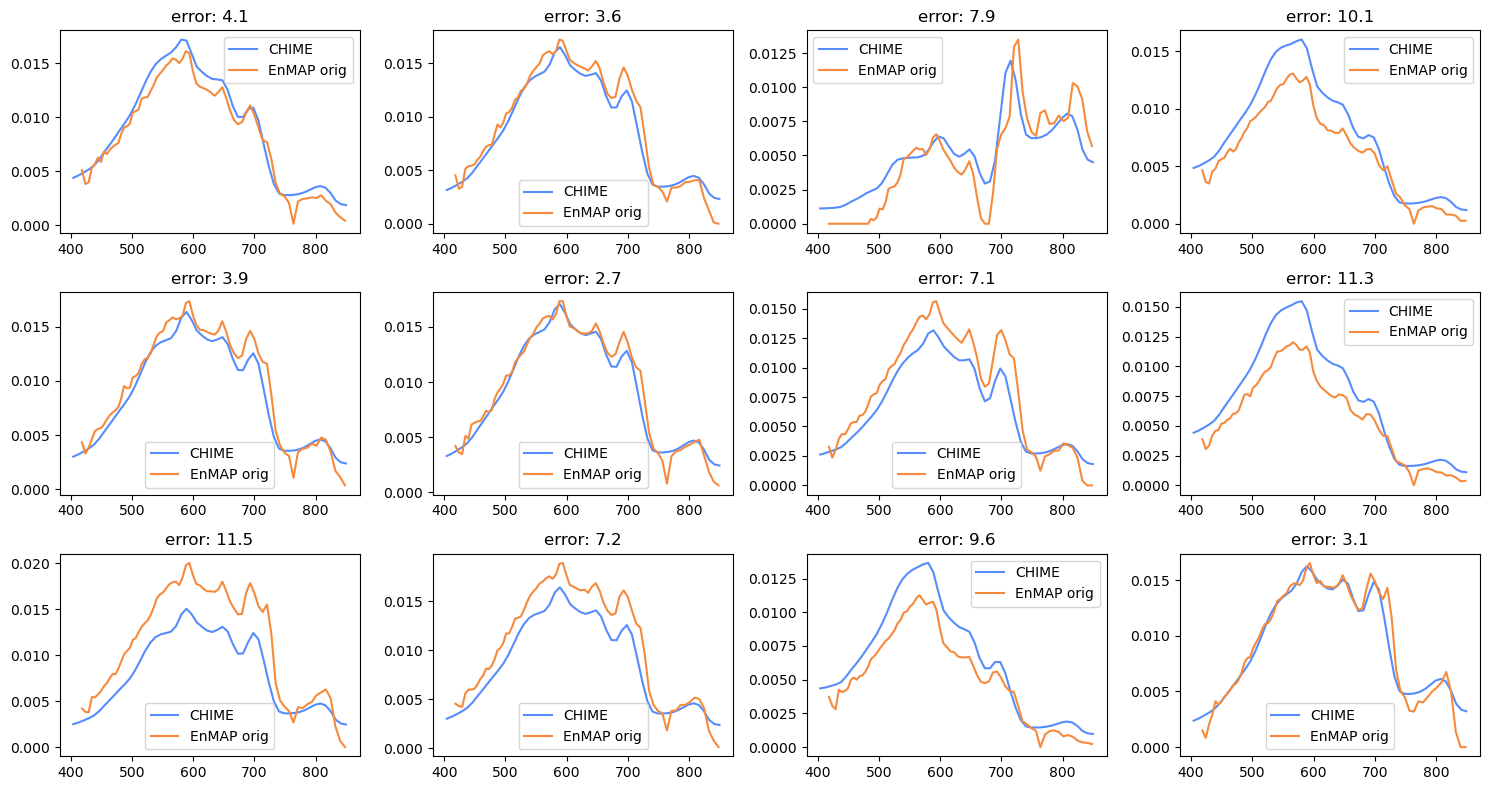

In [123]:
Nx, Ny = (4, 3)
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(15, 8))
ix, iy = (0,0)
for wx, wy in zip(waterX, waterY):
    ax[iy, ix].plot(CHIME_vnir, CHIME_estim[wx, wy, :], '-', label='CHIME')
    ax[iy, ix].plot(wavelengths, Rrs_image[wx, wy, :], '-', label='EnMAP orig')
    # ax[iy, ix].plot(wavelengths, EnMAP_estim[wx, wy, :], '-', label='EnMAP sim')
    ax[iy, ix].legend()
    ax[iy, ix].set_title('error: '+ str(np.round(errorSpec[wx, wy], 1)))
    ix +=1
    if ix == Nx:
        ix=0
        iy+=1
fig.tight_layout()
plt.show()

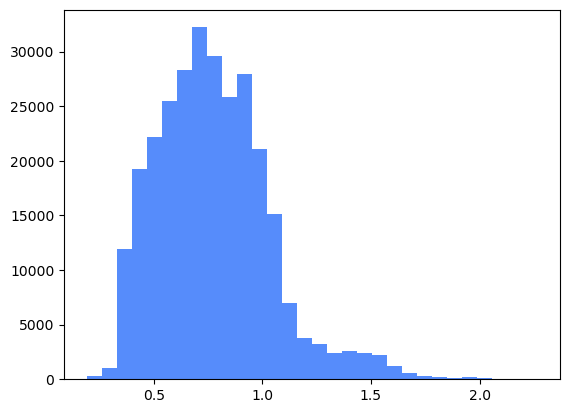

In [129]:
# specMax = np.max(Rrs_image, axis=-1)
# errorSpec2 = np.sum((Rrs_image - EnMAP_estim), axis=-1)/specMax
# bins = np.arange(-50, 20, 1)
plt.hist(np.log10(errorSpec.flatten()), 30)
plt.show()

## Chain 2 - interpolate C_x, forward all

### Step 4 - Interpolate C_x and all varied

In [70]:
varList = []
for v in invIOP.columns.values:
    if v != 'C_phy':
        testv = np.unique(np.round(invIOP[v].values, 6))
        if len(testv) > 2:
            varList.append(v)
varList

['C_0', 'C_2', 'C_3', 'C_4', 'C_6', 'C_Y', 'C_ism', 'b_ratio_d', 'S_cdom']

In [71]:
## Interpolation all varied concentrations ##
k            = 4
n_components = 6

t0 = time.perf_counter()
bp = superpixel_engine.backinterp_pca_knn(
    Rrs_image.reshape(n_pixels, n_obs),
    sp_spectra[valid,:],
    invIOP[varList].values,
    # sp_results['x_hat'],
    # sp_sigma=sp_results['sigma'],
    # sp_A_diag=sp_results['A_diag'],
    k=k, n_components=n_components,
)
t_interp = time.perf_counter() - t0


C_varied_flat  = bp['x_hat']
# sigma_flat  = bp['sigma']
# A_diag_flat = bp['A_diag']

n_fit   = C_varied_flat.shape[-1]
C_varied  = C_varied_flat.reshape(n_rows, n_cols, n_fit)
# sigma_sp  = sigma_flat.reshape(n_rows, n_cols, n_fit)
# A_diag_sp = A_diag_flat.reshape(n_rows, n_cols, n_fit)

print(f'Back-interpolation: {t_interp:.2f} s')
print(f'x_hat shape: {C_varied.shape}')

Back-interpolation: 7.53 s
x_hat shape: (930, 1648, 9)


### Step 5 - Forward Simulations, all spectra
simulate at 1nm intervals

NOTE: needs parallelisation to speed up the forward simulations!

In [ ]:
wl1nm = np.arange(400., 850., 1.)
pre_base = bi_jax.precompute(wl1nm)
pre = {**pre_base}

In [72]:
params = set_default_parameters()

In [73]:
IDnan = np.isnan(Rrs_image[:,:,0])
waterID = np.where(np.logical_not(IDnan))
waterX = waterID[0]
waterY = waterID[1]
# axes[0].plot(waterY, waterX, 'rx')

Rrs_sim_all_Arr = np.zeros((len(waterX), len(wl1nm)))

for i, (wy, wx) in enumerate(zip(waterY, waterX)):  #paramDF.shape[0]:
    for j, p in enumerate(varList):
        params.add(p, value=C_varied[wx, wy, j])

    R_rs_sim_jax = bi_jax.forward(params, pre)
    Rrs_sim_all_Arr[i,:] = R_rs_sim_jax

### Step 6 - Convolve simulations

#### Convolve to CHIME

In [ ]:
SNR = pd.read_csv("Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\CHIME_SNR\SNR_g_No_coeff.csv", header=0)

In [74]:
def ISRF(wl, wl0):
    FWHM = 10.7
    sigma = FWHM/(2*np.sqrt(2*np.log(2)))
    return 1./np.sqrt(2*np.pi*sigma)*np.exp(-1./2.*((wl-wl0)/sigma)**2)

CHIME_vnir = SNR.iloc[:,0].values[SNR.iloc[:,0].values < maxWavelength]

# Rrs_CHIME = np.zeros((len(valid), len(CHIME_vnir)))
weights_Arr = np.zeros((len(wl1nm), len(CHIME_vnir)))
for i, wl0 in enumerate(CHIME_vnir):
    weights = ISRF(wl1nm, wl0)
    weightsnorm = weights / np.sum(weights)
    weights_Arr[:,i] = weightsnorm

Rrs_CHIME_all = np.matmul(Rrs_sim_all_Arr, weights_Arr)

#### Convolve to EnMAP

In [ ]:
EnMAP_SRF = pd.read_csv("E:\Documents\projects\EnsAD\c2rcc_test\EnMAP_SRF\EnMAP_Spectral_Bands.txt", header=0, sep='\t')

In [75]:
def ISRF_EnMAP(wl, wl0):
    ind_, ind = find_closest(EnMAP_SRF['CW (nm)'], wl0)
    FWHM = EnMAP_SRF['FWHM (nm)'].values[ind]
    sigma = FWHM/(2*np.sqrt(2*np.log(2)))
    return 1./np.sqrt(2*np.pi*sigma)*np.exp(-1./2.*((wl-wl0)/sigma)**2)

EnMAP_vnir = wavelengths

# Rrs_EnMAP = np.zeros((len(valid), len(EnMAP_vnir)))
weights_Arr = np.zeros((len(wl1nm), len(EnMAP_vnir)))
for i, wl0 in enumerate(EnMAP_vnir):
    weights = ISRF_EnMAP(wl1nm, wl0)
    weightsnorm = weights / np.sum(weights)
    weights_Arr[:,i] = weightsnorm

Rrs_EnMAPall = np.matmul(Rrs_sim_all_Arr, weights_Arr)

In [76]:
Rrs_EnMAPall.shape

(286874, 73)

#### To 3D data array

In [77]:
Rrs3D_EnMAP = np.zeros(Rrs_image.shape)
for i,(wy, wx) in enumerate(zip(waterY, waterX)):
    Rrs3D_EnMAP[wx, wy,:] = Rrs_EnMAPall[i,:]

In [79]:
Rrs3D_CHIME = np.zeros((Rrs_image.shape[0], Rrs_image.shape[1], Rrs_CHIME_all.shape[1]))
for i,(wy, wx) in enumerate(zip(waterY, waterX)):
    Rrs3D_CHIME[wx, wy,:] = Rrs_CHIME_all[i,:]

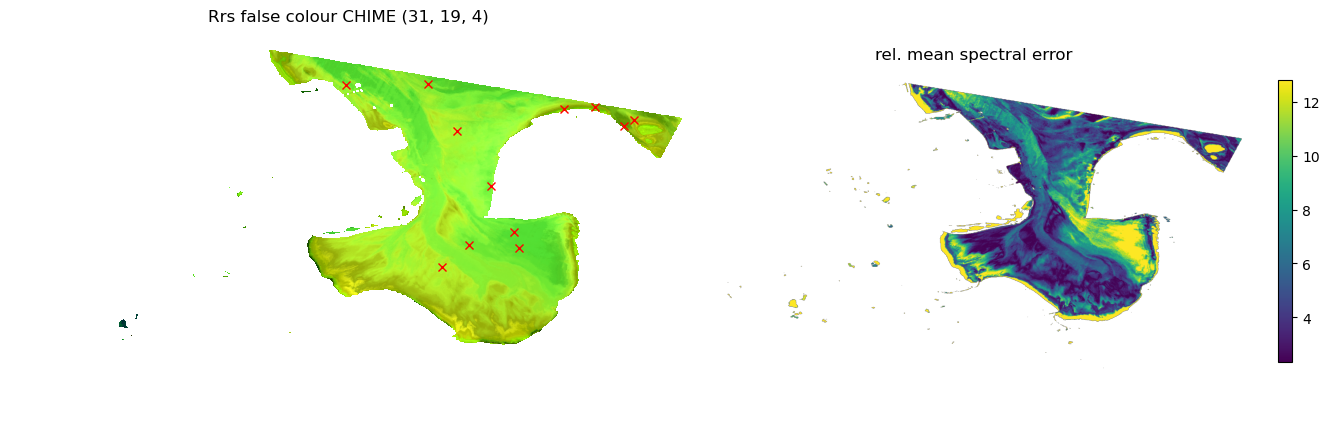

In [93]:
## RGB CHIME
ind665_C, ind665C = find_closest(CHIME_vnir, 665)
ind560_C, ind560C = find_closest(CHIME_vnir, 560)
ind440_C, ind440C = find_closest(CHIME_vnir, 440)

IDnan = np.isnan(Rrs_image[:,:,0])

# False-colour RGB for overlay
rgb_bands = [ind665C, ind560C, ind440C]   # B04, B03, B02 → R, G, B
rgb = Rrs3D_CHIME[..., rgb_bands]
for i in range(rgb.shape[2]):
    rgb[IDnan, i] = np.nan
rgb = (rgb - np.nanpercentile(rgb, 2)) / (np.nanpercentile(rgb, 98) - np.nanpercentile(rgb, 2))
rgb = np.clip(rgb, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(rgb, origin='upper')

## random choice spectrum from water: EnMAP, CHIME
waterID = np.where(np.logical_not(IDnan))
selectID = np.random.choice(np.arange(0, len(waterID[0]),1), size=12, replace=False)
waterX = waterID[0][selectID]
waterY = waterID[1][selectID]
axes[0].plot(waterY, waterX, 'rx')
# axes.text(waterY, waterX, [str(i) for i in range(12)], color='red')

BandStr = str(ind665C) + ', ' + str(ind560C) + ', ' + str(ind440C)
axes[0].set_title('Rrs false colour CHIME ('+BandStr +')')
axes[0].axis('off')

## Error EnMAP to CHIME
# only possible with EnMAP to EnMAP!
specMax = np.max(Rrs_image, axis=-1)
errorSpec2 = np.sum(np.abs(Rrs_image - Rrs3D_EnMAP), axis=-1)/specMax
vmin, vmax = np.nanpercentile(errorSpec2, [2, 90])
im = axes[1].imshow(errorSpec2, origin='upper', vmin=vmin, vmax=vmax)
axes[1].set_title('rel. mean spectral error')
axes[1].axis('off')
fig.colorbar(im, ax=axes[1], shrink=0.6)
plt.tight_layout()
plt.show()

### compare both chains

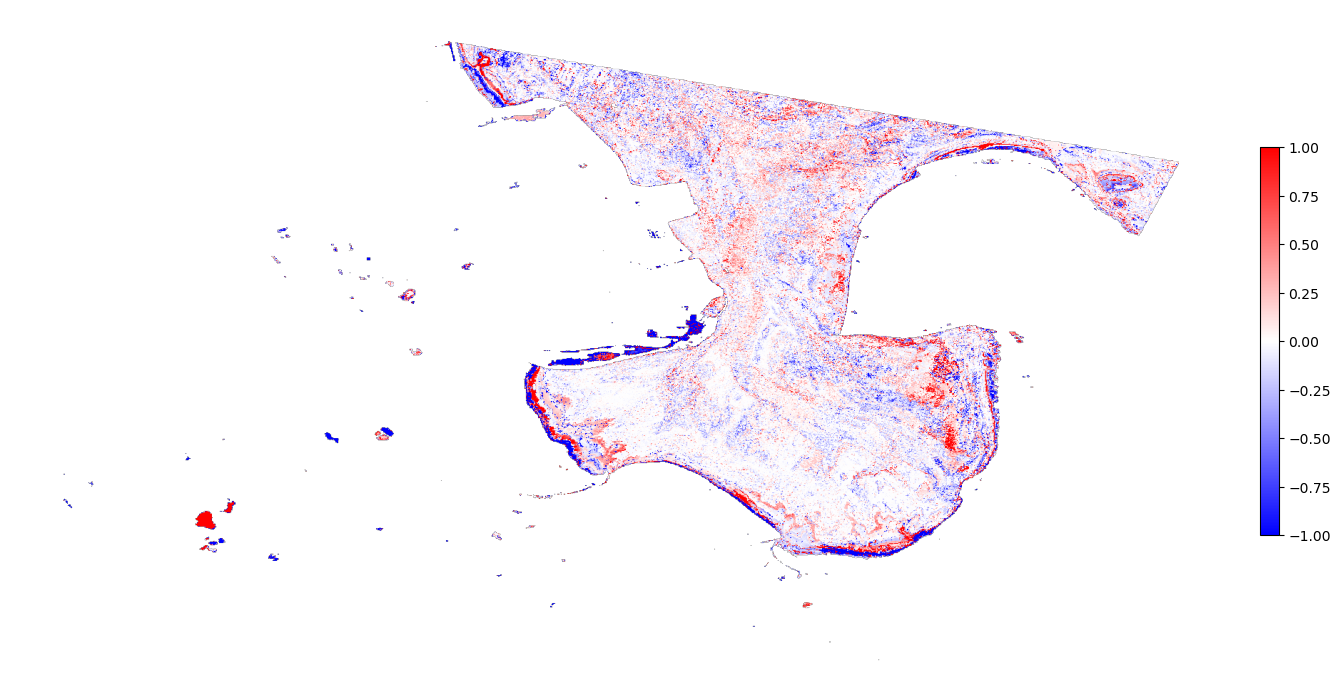

In [94]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
im = ax.imshow(errorSpec-errorSpec2, origin='upper', vmin=-1, vmax=1, cmap='bwr')
ax.axis('off')
fig.colorbar(im, ax=ax, shrink=0.4)
fig.tight_layout()
plt.show()

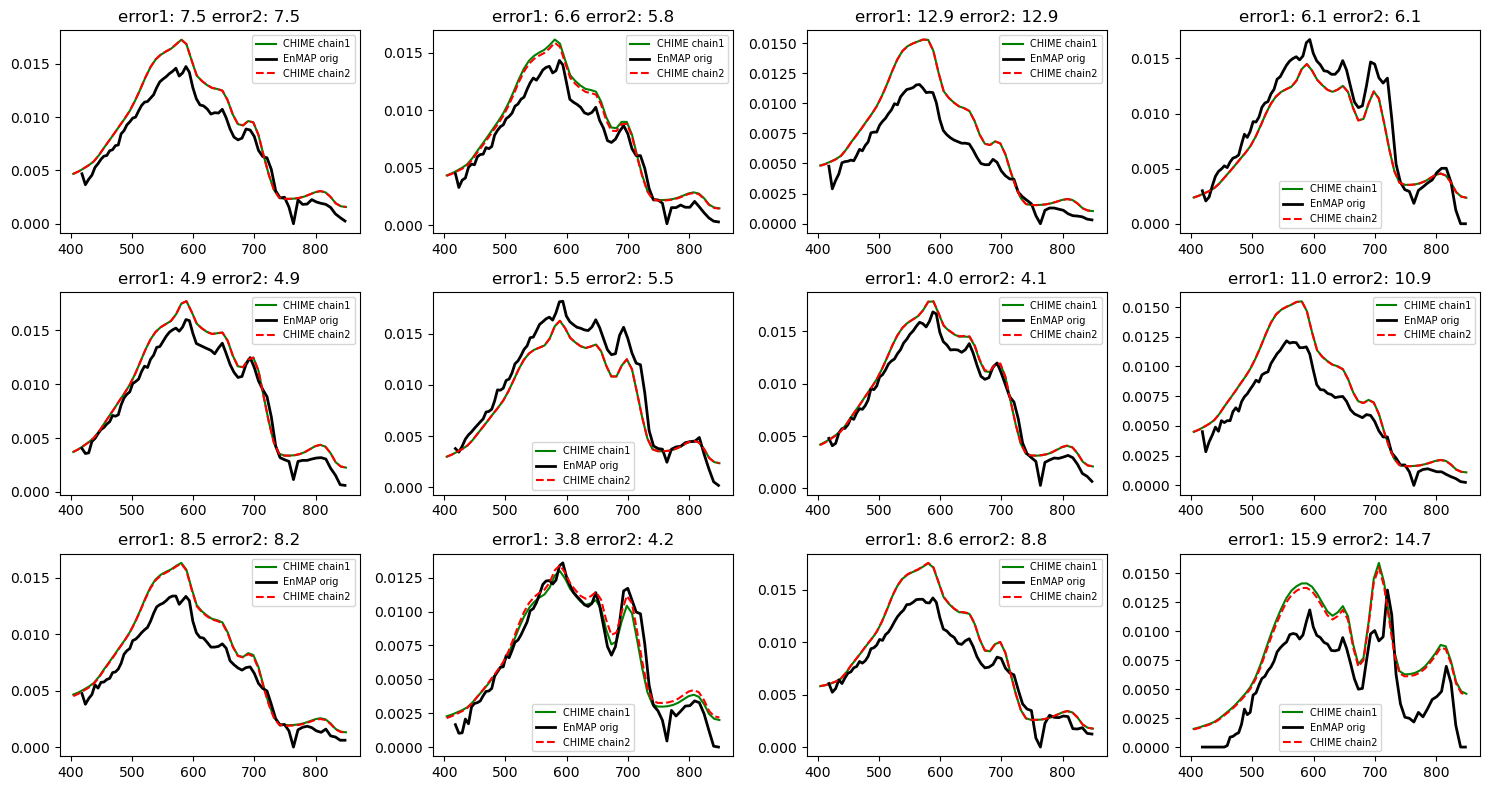

In [96]:
Nx, Ny = (4, 3)
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(15, 8))
ix, iy = (0,0)
for wx, wy in zip(waterX, waterY):
    ax[iy, ix].plot(CHIME_vnir, CHIME_estim[wx, wy, :], 'g-', label='CHIME chain1')
    ax[iy, ix].plot(wavelengths, Rrs_image[wx, wy, :], 'k-', lw=2, label='EnMAP orig')
    # ax[iy, ix].plot(wavelengths, EnMAP_estim[wx, wy, :], '-', label='EnMAP sim chain1')
    # ax[iy, ix].plot(wavelengths, Rrs3D_EnMAP[wx, wy, :], '-', label='EnMAP sim chain2')
    ax[iy, ix].plot(CHIME_vnir, Rrs3D_CHIME[wx, wy, :], 'r--', label='CHIME chain2')
    ax[iy, ix].legend(fontsize=7)
    ax[iy, ix].set_title('error1: '+ str(np.round(errorSpec[wx, wy], 1))+ ' error2: '+ str(np.round(errorSpec2[wx, wy], 1)))
    ix +=1
    if ix == Nx:
        ix=0
        iy+=1
fig.tight_layout()
plt.show()

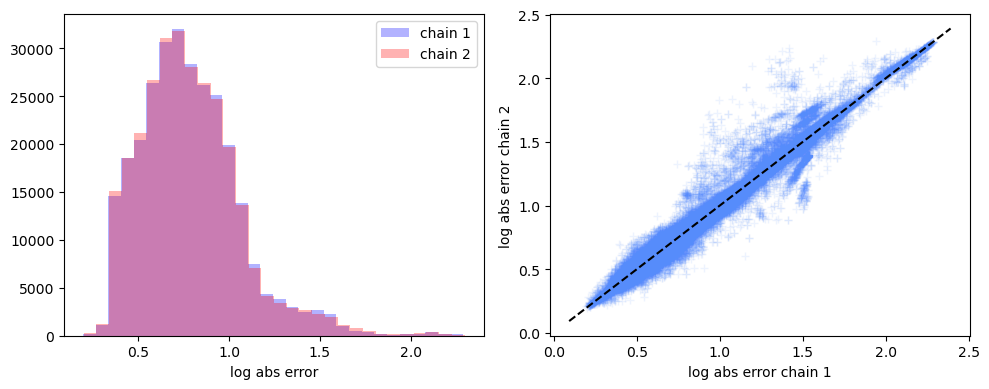

In [105]:
fig, ax = plt.subplots(1,2, figsize=(10, 4))
ax[0].hist(np.log10(errorSpec[:,:].flatten()), bins=30, color='blue', alpha=0.3, label='chain 1')
ax[0].hist(np.log10(errorSpec2[:,:].flatten()), bins=30, color='red', alpha=0.3, label='chain 2')
ax[0].set_xlabel('log abs error')
ax[0].legend()
ax[1].plot(np.log10(errorSpec[:,:].flatten()), np.log10(errorSpec2[:,:].flatten()), '+', alpha=0.1)
ax[1].set_ylabel('log abs error chain 2')
ax[1].set_xlabel('log abs error chain 1')
xlim= ax[1].get_xlim()
ax[1].plot(xlim, xlim, 'k--')
fig.tight_layout()
plt.show()

## Step 7 - CHIME Noise
1. Convert Rrs into Radiance
2. Simplistic transfer to TOA -> ? This needs an estimate for upwelling transmittance ?!
3. SNR

### Reflectance to Radiance

In [11]:
## sun irradiance convolved to CHIME bands!
from netCDF4 import Dataset
# fname = "Y:\EnMAP\solar_irradiance\hybrid_reference_spectrum_p025nm_resolution_c2022-11-30_with_unc.nc" # spectral resolution 0.025nm
fname = "Y:\EnMAP\solar_irradiance\hybrid_reference_spectrum_c2022-11-30_with_unc.nc" # spectral resolution 0.001nm
F0 = Dataset(fname, 'r')

wavelength = F0.variables['Vacuum Wavelength'][:]
SSI = F0.variables['SSI'][:]
ID = np.logical_and(wavelength>380, wavelength<900)
wavelength = wavelength[ID]
SSI = SSI[ID]

In [46]:
def convolve_CHIME_weights(wavelength, CHIME_vnir):
    def ISRF(wl, wl0):
        FWHM = 10.7
        sigma = FWHM/(2*np.sqrt(2*np.log(2)))
        return 1./np.sqrt(2*np.pi*sigma)*np.exp(-1./2.*((wl-wl0)/sigma)**2)

    weights_Arr = np.zeros((len(wavelength), len(CHIME_vnir)))
    for i, wl0 in enumerate(CHIME_vnir):
        weights = ISRF(wavelength, wl0)
        weightsnorm = weights / np.sum(weights)
        weights_Arr[:,i] = weightsnorm

    return weights_Arr

In [34]:
## F0 Unit: W/m2/nm
weights_Arr = convolve_CHIME_weights(wavelength, CHIME_vnir)
F0_CHIME = np.zeros(len(CHIME_vnir))
for i in range(len(CHIME_vnir)):
    F0_CHIME[i] = np.sum(SSI * weights_Arr[:,i])
F0_CHIME

array([1.64156996, 1.75775901, 1.73977994, 1.64227608, 1.78659959,
       1.97170477, 2.05649303, 2.065514  , 2.05703482, 2.05616871,
       1.96788862, 1.97901731, 1.95702733, 1.89630917, 1.86260923,
       1.91029452, 1.90341072, 1.89577575, 1.87688988, 1.85035452,
       1.85148112, 1.84123139, 1.80051466, 1.78498864, 1.75343149,
       1.70062642, 1.67454297, 1.6512079 , 1.62233146, 1.58621937,
       1.52999246, 1.53994666, 1.52267605, 1.4946394 , 1.4669832 ,
       1.4327456 , 1.40356164, 1.37056378, 1.34120493, 1.31702553,
       1.28655928, 1.26806916, 1.24721567, 1.22012157, 1.19674832,
       1.17989638, 1.15454741, 1.1308063 , 1.1091067 , 1.08709404,
       1.06377244, 1.04408225, 1.02439957, 0.97993641])

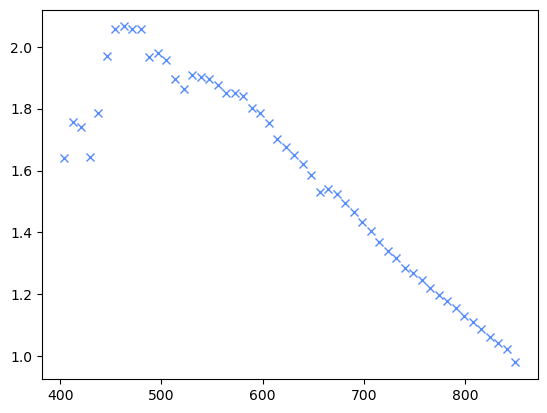

In [35]:
plt.plot(CHIME_vnir, F0_CHIME, 'x')
plt.show()

In [89]:
# reflectance[i] = radiance * math.pi / (E0 * np.cos(np.radians(theta_s)))
## Geometry of EnMAP scene
theta_sun = sun_dict['zenith']
dist = np.asarray(earth_distance(pd.to_datetime(datetime)))
Ed_TOA = F0_CHIME / dist**2 *np.cos(np.deg2rad(theta_sun))

In [92]:
L_surf_CHIME = CHIME_estim / np.pi * Ed_TOA # Chain 1, Unit: W/sr/m2/nm
# L_surf_CHIME = Rrs3D_CHIME / np.pi * Ed_TOA # Chain 2

#### Rayleigh transmittance
single geometry for the scene EnMAP

view_zenith = 7.0

at lat/lon of Tile center point


In [40]:
import json
def json_as_numpy(dct):
	return {key: np.array(value) for key, value in dct.items()}
# constants
AVO = 6.0221367E+23  # Avogadro's number
m_a_zero = 28.9595  # Mean molecular weight of dry air (zero H2O)
g0_45 = 980.616  # Acceleration of gravity (sea level and 458 latitude)
Ns = 2.5469E19  # Molecular density of gas in molecules / cm3 (288.15K, 1013.25mb)

#Ns = Ns * 288.15/243.15 #-30°C in greenland in that summer..

# constants describing the state of the atmosphere and which we don't know; better values may be used if known
CO2 = 3.6E-4  # CO2 concentration at pixel; typical values are 300 to 360 ppm; here: parts per volumn
C_CO2 = 360. / 10000.  # CO2 concentration in part per volume per percent
m_a = 15.0556 * CO2 + m_a_zero  # mean molecular weight of dry air as function of actual CO2

# other constants
PA = 0.9587256  # Rayleigh Phase function, molecular asymetry factor 1
PB = 1. - PA  # Rayleigh Phase function, molecular asymetry factor 2

with open('C:\\Users\Dagmar\PycharmProjects\geoinfopy\sandbox\dagmar\OLCI_smile_correction\\test\\raycorr_auxdata.json', 'r') as fp:
    obj = json.load(fp, object_hook=json_as_numpy)
# json_str = json.dumps(new_aux, cls=JSONNumpyEncoder, indent=2)
# print(json_str)
# obj = json.loads(json_str, object_hook=json_as_numpy)
# rayADF = new_aux
rayADF = obj
ray_coeff_matrix = rayADF['ray_coeff_matrix']

tpoly = rayADF['tau_ray']  # Polynomial coefficients for Rayleigh transmittance

# Rayleigh transmittances and spherical albedo
nbands = CHIME_estim.shape[-1]
tR_thetaS = np.zeros(nbands, dtype=np.float32)  # Rayleigh Transmittance sun - surface
tR_thetaV = np.zeros(nbands, dtype=np.float32)  # Rayleigh Transmittance surface - sensor
sigma = np.zeros(nbands)
alt = 0. # m
press0 = 1032. # hPa
theta_view= 7.0
taur = np.zeros(nbands)

# Calculate the Rayleigh cross section, which depends only on wavelength but not on air pressure
def Rayleigh_crosssection(lam_nm):
    # lam_nm = CHIME_vnir[i]
    lam =  lam_nm / 1000.0  # wavelength in micrometer
    lam2 = lam_nm / 1.E7  # wavelength in cm
    F_N2 = 1.034 + 0.000317 / (lam ** 2)  # King factor of N2
    F_O2 = 1.096 + 0.001385 / (lam ** 2) + 0.0001448 / (lam ** 4)  # King factor of O2
    F_air = (78.084 * F_N2 + 20.946 * F_O2 + 0.934 * 1 + C_CO2 * 1.15) / (
            78.084 + 20.946 + 0.934 + C_CO2)  # depolarization ratio or King Factor, (6+3rho)/(6-7rho)
    n_ratio = 1 + 0.54 * (CO2 - 0.0003)
    #refractive index of dry air with 300ppm CO2:
    n_1_300 = (8060.51 + (2480990. / (132.274 - lam ** (-2))) + (17455.7 / (39.32957 - lam ** (-2)))) / 1.E8
    ## old: nCO2 = n_ratio * (1 + n_1_300)  # reflective index at CO2; THIS WAS AN ERROR!
    nCO2 = n_ratio * n_1_300 + 1  # reflective index at CO2
    return (24 * np.pi**3 * (nCO2**2 - 1)**2) / (lam2**4 * Ns**2 * (nCO2**2 + 2)**2) * F_air

sigma = Rayleigh_crosssection(CHIME_vnir)

# Calculation to get the pressure
z = alt  # altitude at pixel in meters, taken from MERIS tie-point grid
z = max(z, 0)  # clip to sea level
Psurf0 = press0  # pressure at sea level in hPa, taken from MERIS tie-point grid
Psurf = Psurf0 * (1. - 0.0065 * z / 288.15) ** 5.255  # air pressure at the pixel (i.e. at altitude) in hPa, using the international pressure equation
P = Psurf * 1000.  # air pressure at pixel location in dyn / cm2, which is hPa * 1000
# calculation to get the constant of gravity at the pixel altitude, taking the air mass above into account
dphi = np.radians(lat_mean)  # latitude in radians
cos2phi = np.cos(2 * dphi)
g0 = g0_45 * (1 - 0.0026373 * cos2phi + 0.0000059 * cos2phi ** 2)
zs = 0.73737 * z + 5517.56  # effective mass-weighted altitude
g = g0 - (3.085462E-4 + 2.27E-7 * cos2phi) * zs + (7.254E-11 + 1E-13 * cos2phi) * zs**2 - (1.517E-17 + 6E-20 * cos2phi) * zs**3
# calculations to get the Rayleigh optical thickness
factor = (P * AVO) / (m_a * g)
taur = sigma *factor

# Calculate Rayleigh Phase function
ts = np.radians(theta_sun)  # sun zenith angle in radian
cts = np.cos(ts)  # cosine of sun zenith angle
sts = np.sin(ts)  # sinus of sun zenith angle
tv = np.radians(theta_view)  # view zenith angle in radian
ctv = np.cos(tv)  # cosine of view zenith angle
stv = np.sin(tv)  # sinus of view zenith angle
airmass = 1. / cts + 1. / ctv  # air mass

# polynomial coefficients tpoly0, tpoly1 and tpoly2 from MERIS LUT
tRs = ((2. / 3. + cts) + (2. / 3. - cts) * np.exp(-taur / cts)) / (4. / 3. + taur)
# Rayleigh Transmittance sun - surface
tR_thetaS = tpoly[0] + tpoly[1] * tRs + tpoly[2] * tRs ** 2
tRv = ((2. / 3. + ctv) + (2. / 3. - ctv) * np.exp(-taur / ctv)) / (4. / 3. + taur)
# Rayleigh Transmittance surface - sensor
tR_thetaV = tpoly[0] + tpoly[1] * tRv + tpoly[2] * tRv ** 2

Processing ...


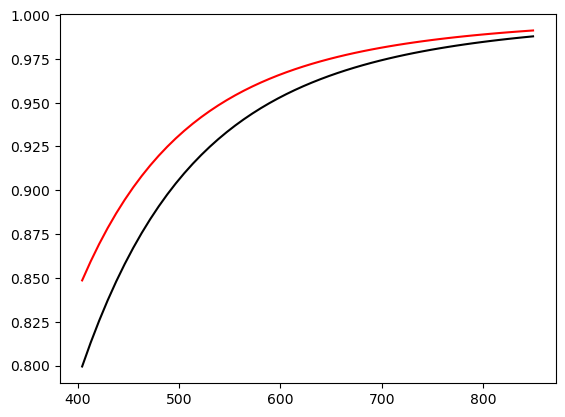

In [41]:
plt.plot(CHIME_vnir, tR_thetaS, 'k-')
plt.plot(CHIME_vnir, tR_thetaV, 'r-')
plt.show()

#### L_TOA estimate, convolve L_ref, SNR value per band and pixel
Lref Unit: W/sr/m2/micron! -> 10^-3 * W/sr/m2/nm

In [47]:
pathSNR = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\CHIME_SNR\\"

# SNR = pd.read_csv(pathSNR + "SNR_g_No_coeff.csv", header=0)
Ref = pd.read_csv(pathSNR + "SSRD_AD11 CHIME radiance levels v4.csv", header=0)
# convolve to CHIME
weights_Arr = convolve_CHIME_weights(Ref.iloc[:,0], CHIME_vnir)
L_ref_CHIME = np.zeros(len(CHIME_vnir))
for i in range(len(CHIME_vnir)):
    L_ref_CHIME[i] = np.sum(Ref.iloc[:,2] * weights_Arr[:,i])

In [94]:
L_TOA_CHIME = np.asarray(10.*L_surf_CHIME * tR_thetaV) # tR_thetaV is an astropy class! W/sr/m2/nm -> 10^3 * W/sr/m2/micron
rLTOA = 1000. * L_TOA_CHIME / L_ref_CHIME
IDbands = np.logical_and(SNR.iloc[:,0]>=np.min(CHIME_vnir), SNR.iloc[:,0]<=np.max(CHIME_vnir))

for j in range(rLTOA.shape[2]):
    rLTOA[IDnan, j] = np.nan

SNR_CHIME =  rLTOA * SNR.g.values[IDbands] * 1./np.sqrt(rLTOA + SNR.N0.values[IDbands])

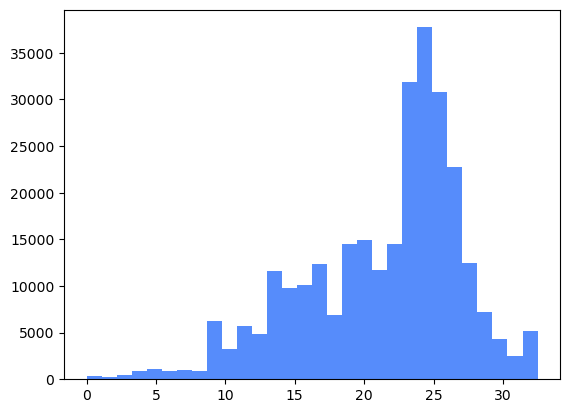

In [95]:
plt.hist(SNR_CHIME[:,:, 0].reshape(SNR_CHIME.shape[0]*SNR_CHIME.shape[1]), 30)
plt.show()

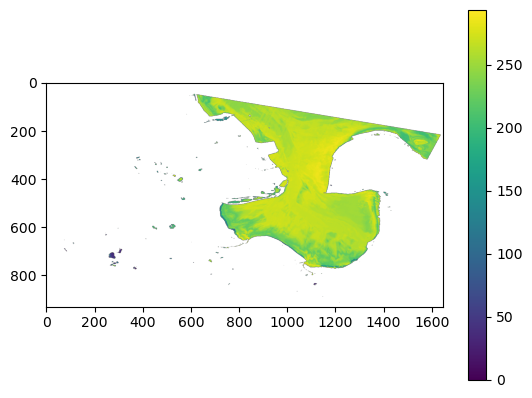

In [97]:
plt.imshow(SNR_CHIME[:,:, 20])
plt.colorbar()
plt.show()

#### Apply SNR to Rrs spectra

In [98]:
## Noise to remote sensing reflectance at surface
NOISE_Rrs = 10. * CHIME_estim / SNR_CHIME * np.random.normal(size=CHIME_estim.shape)

C:\Users\Dagmar\AppData\Local\Temp\ipykernel_12332\1670591167.py:2: RuntimeWarning: invalid value encountered in divide
  NOISE_Rrs = 10. * CHIME_estim / SNR_CHIME * np.random.normal(size=CHIME_estim.shape)


In [99]:
CHIME_estim_withNoise = CHIME_estim + NOISE_Rrs

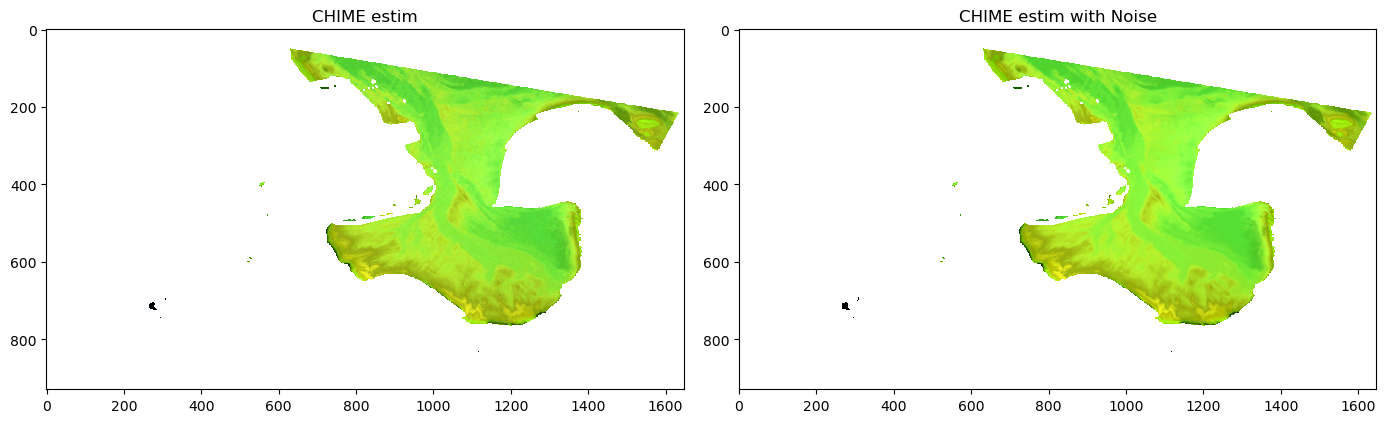

In [100]:
# False-colour RGB for overlay
rgb_bands = [ind665C, ind560C, ind440C]   # B04, B03, B02 → R, G, B
rgb_noise = CHIME_estim_withNoise[..., rgb_bands]
for i in range(rgb_noise.shape[2]):
    rgb_noise[IDnan, i] = np.nan
rgb_noise = (rgb_noise - np.nanpercentile(rgb_noise, 2)) / (np.nanpercentile(rgb_noise, 98) - np.nanpercentile(rgb_noise, 2))
rgb_noise = np.clip(rgb_noise, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(rgb_noise, origin='upper')
axes[0].set_title('CHIME estim')
axes[1].imshow(rgb, origin='upper')
axes[1].set_title('CHIME estim with Noise')
fig.tight_layout()
plt.show()

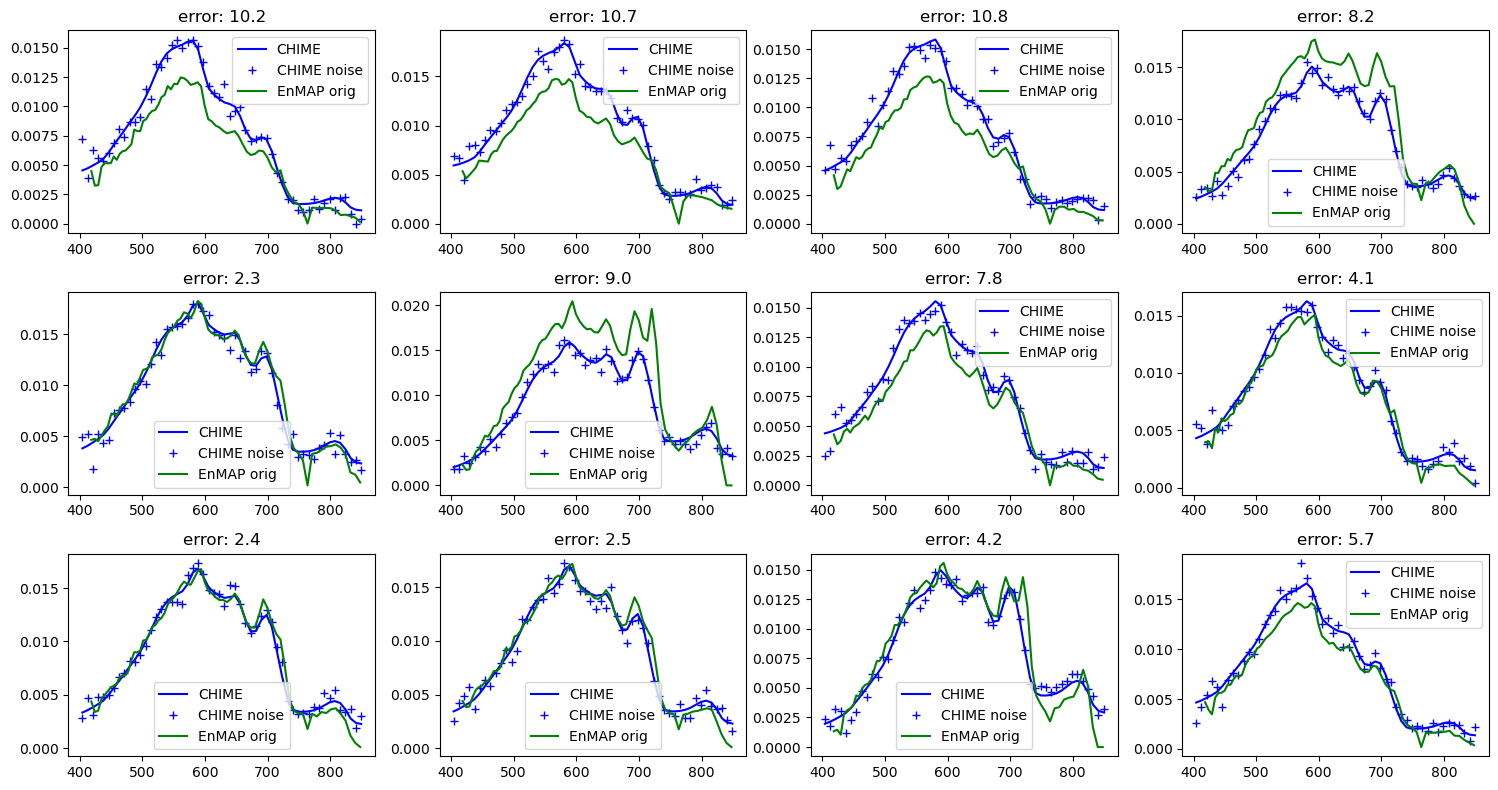

In [102]:
Nx, Ny = (4, 3)
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(15, 8))
ix, iy = (0,0)
for wx, wy in zip(waterX, waterY):
    ax[iy, ix].plot(CHIME_vnir, CHIME_estim[wx, wy, :], 'b-', label='CHIME')
    ax[iy, ix].plot(CHIME_vnir, CHIME_estim_withNoise[wx, wy, :], 'b+', label='CHIME noise')
    ax[iy, ix].plot(wavelengths, Rrs_image[wx, wy, :], 'g-', label='EnMAP orig')
    # ax[iy, ix].plot(wavelengths, EnMAP_estim[wx, wy, :], '-', label='EnMAP sim')
    ax[iy, ix].legend()
    ax[iy, ix].set_title('error: '+ str(np.round(errorSpec[wx, wy], 1)))
    ix +=1
    if ix == Nx:
        ix=0
        iy+=1
fig.tight_layout()
plt.show()